# Grouping Countries for Tourism Investment Using Unsupervised Learning

**Author:** Takunda Manhongo | Student ID: R2418440  
**Programme:** BSc Data Science and Systems, University of Zimbabwe  
**Date:** March 2026  
**Dataset:** Country Statistics, UCI Machine Learning Repository (229 countries)

---

## Table of Contents
1. Context and Objective
2. Algorithms Overview
3. Setup and Imports
4. Load and Inspect Data
5. Data Cleaning
6. Feature Selection
7. Missing Value Imputation (Median by Region)
8. Exploratory Data Analysis
9. Data Scaling
10. Hierarchical Clustering
    - 10.1 Cophenetic Correlation
    - 10.2 Dendrogram Visualisation
    - 10.3 Fitting the Best Model
    - 10.4 Cluster Profiling
11. K-Means Clustering
    - 11.1 Elbow Method
    - 11.2 Evaluation Metrics
    - 11.3 Fitting the Best Model
    - 11.4 Cluster Profiling
12. Algorithm Comparison
13. PCA Dimensionality Reduction
14. Strategic Tourism Investment Insights
15. Conclusions

---

## 1. Context and Objective

Tourism is a directly measurable economic activity enabling accurate analysis and effective strategic planning. Identifying countries with similar socioeconomic, infrastructural, and technological profiles allows investors and policymakers to make targeted, data-driven tourism investment decisions.

**Objective:** Identify distinct groups of countries based on key socioeconomic indicators to guide strategic tourism investment decisions.

**Approach:** Hierarchical Clustering is the primary algorithm, using Cophenetic Correlation to identify the best linkage method. K-Means is fitted alongside for comparison. For both algorithms the optimal K is determined by evaluation metrics, not by assumption.

## 2. Algorithms Overview

| Algorithm | Role | Key Advantage |
|---|---|---|
| Hierarchical Clustering | Main | Cophenetic correlation guides linkage; K chosen from data |
| K-Means Clustering | Comparison | Fast, scalable; K chosen by Silhouette and Elbow |
| PCA | Supporting | 2D visualisation of cluster separation |

**Cophenetic Correlation** measures how faithfully the dendrogram preserves the original pairwise distances between countries. A higher value means the tree is a more reliable representation of the true distances — guiding us to the best linkage method.

## 3. Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                              calinski_harabasz_score, silhouette_samples)
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet, fcluster
from scipy.spatial.distance import pdist

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
np.random.seed(42)

plt.rcParams.update({
    'figure.dpi': 120, 'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa', 'axes.grid': True,
    'grid.alpha': 0.35, 'grid.linestyle': '--',
    'axes.spines.top': False, 'axes.spines.right': False,
})

PALETTE = ['#3498db','#e74c3c','#2ecc71','#9b59b6','#f39c12','#1abc9c']

## 4. Load and Inspect Data

In [2]:
data = pd.read_csv('country_stats.csv')
print('Shape:', data.shape)
data.sample(n=10, random_state=1)

Shape: (229, 22)


,country,Region,Surface area (km2),Population in thousands (2017),"Population density (per km2, 2017)","Sex ratio (m per 100 f, 2017)",GDP: Gross domestic product (million current US$),Economy: Agriculture (% of GVA),Economy: Industry (% of GVA),Economy: Services and other activity (% of GVA),International trade: Exports (million US$),International trade: Imports (million US$),International trade: Balance (million US$),"Fertility rate, total (live births per woman)",Infant mortality rate (per 1000 live births),Health: Total expenditure (% of GDP),Education: Government expenditure (% of GDP),Mobile-cellular subscriptions (per 100 inhabitants),Individuals using the Internet (per 100 inhabitants),Threatened species (number),CO2 emission estimates (million tons/tons per capita),"Energy production, primary (Petajoules)"
39,Central African Republic,MiddleAfrica,622984,4659,7.5,97.3,1633,34.9,24.8,40.4,213,147,66,5.1,93.5,4.2,1.2,20.4,60,35.6,19,5
170,Saint Kitts and Nevis,Caribbean,261,55,212.9,97.0,876,1.2,28.1,70.7,51,332,-280,-99,-99,5.1,2.8,131.8,52,42.3,0,59
93,Hungary,EasternEurope,93024,9722,107.4,90.7,121715,4.1,31.9,64.0,103071,92044,11027,1.3,4.9,7.4,4.7,118.9,66,22.8,423,97
62,Egypt,NorthernAfrica,1002000,97553,98.0,102.3,315917,11.2,36.3,52.5,22507,58053,-35545,3.4,18.9,5.6,...,111,156,0.1,3509,36
199,Tajikistan,CentralAsia,142600,8921,63.7,100.9,7853,25,28.0,47.1,899,3030,-2132,3.5,38.9,6.9,5.2,98.6,45,3,76,14
173,Saint Vincent and the Grenadines,Caribbean,389,110,281.8,101.7,738,7.5,17.2,75.3,47,335,-288,2,16.5,8.6,...,103.6,58,69.2,0,29
38,Cayman Islands,Caribbean,264,62,256.5,100.4,3726,0.3,7.5,92.2,18,991,-972,...,-99,-99.0,-99,155.5,74,52.9,-99,130
124,Mali,WesternAfrica,1240192,18542,15.2,100.2,13100,39.9,19.6,40.5,3030,2510,520,6.4,78.5,7.0,3.7,139.6,42,3.9,55,4
107,Kenya,EasternAfrica,591958,49700,87.3,98.8,63399,32,19.0,49.0,5688,14109,-8420,4.1,39.4,5.7,5.3,80.7,480,7.7,750,20
89,Guyana,SouthAmerica,214969,778,4.0,101.9,3282,17.6,31.7,50.6,1453,1625,-172,2.6,33.2,5.2,3.2,67.2,94,84,7,46


In [3]:
df = data.copy()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 229 entries, 0 to 228
Data columns (total 22 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   country                                                229 non-null    str    
 1   Region                                                 229 non-null    str    
 2   Surface area (km2)                                     229 non-null    str    
 3   Population in thousands (2017)                         229 non-null    int64  
 4   Population density (per km2, 2017)                     229 non-null    float64
 5   Sex ratio (m per 100 f, 2017)                          229 non-null    float64
 6   GDP: Gross domestic product (million current US$)      229 non-null    int64  
 7   Economy: Agriculture (% of GVA)                        229 non-null    str    
 8   Economy: Industry (% of GVA)                           229 no

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,229,229,Afghanistan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,229,22,Caribbean,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Surface area (km2),229,225,-99,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Population in thousands (2017),229.0,NaN,NaN,NaN,32756.79476,133275.079914,1.0,431.0,5448.0,19193.0,1409517.0
"Population density (per km2, 2017)",229.0,NaN,NaN,NaN,462.824891,2305.384253,0.1,35.9,88.1,222.8,25969.8
"Sex ratio (m per 100 f, 2017)",229.0,NaN,NaN,NaN,100.202183,28.327837,-99.0,96.4,99.0,101.7,301.2
GDP: Gross domestic product (million current US$),229.0,NaN,NaN,NaN,321433.886463,1478689.863851,-99.0,2078.0,16251.0,117955.0,18036648.0
Economy: Agriculture (% of GVA),229,139,-99,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Economy: Industry (% of GVA),229.0,NaN,NaN,NaN,15.958952,38.684631,-99.0,15.4,25.5,32.8,79.9
Economy: Services and other activity (% of GVA),229.0,NaN,NaN,NaN,46.408734,48.60373,-99.0,47.3,59.5,70.7,94.0


## 5. Data Cleaning

The dataset contains encoded missing values that must be replaced with NaN before analysis:
- **-99** — numeric placeholder for missing values
- **...** — string placeholder for unavailable data
- **~0 / ~0.0** — very small values encoded as strings

In [5]:
# Strip units from column names
cols_init = df.columns.tolist()
cols_new  = [item.split('(')[0].rstrip() for item in cols_init]
df.columns = cols_new
cols = df.columns

epsilon = 0.00001
for item in cols:
    df[item] = df[item].apply(lambda x: np.nan if x in [-99, '-99'] else x)
    df[item] = df[item].apply(lambda x: np.nan if x == '...' else x)
    df[item] = df[item].apply(lambda x: epsilon if x in ['~0', '~0.0'] else x)

# Convert object columns that should be numeric
type_cols = [
    'Surface area', 'Economy: Agriculture',
    'International trade: Exports', 'International trade: Imports',
    'International trade: Balance', 'Fertility rate, total',
    'Infant mortality rate', 'Education: Government expenditure',
    'Mobile-cellular subscriptions', 'Threatened species'
]
for item in type_cols:
    df[item] = pd.to_numeric(df[item], errors='coerce')

print('Cleaning complete.')
df.head()

Cleaning complete.


,country,Region,Surface area,Population in thousands,Population density,Sex ratio,GDP: Gross domestic product,Economy: Agriculture,Economy: Industry,Economy: Services and other activity,International trade: Exports,International trade: Imports,International trade: Balance,"Fertility rate, total",Infant mortality rate,Health: Total expenditure,Education: Government expenditure,Mobile-cellular subscriptions,Individuals using the Internet,Threatened species,CO2 emission estimates,"Energy production, primary"
0,Afghanistan,SouthernAsia,652864.0,35530,54.4,106.3,20270.0,23.3,23.3,53.3,1458.0,3568.0,-2110.0,5.3,68.6,8.2,3.3,61.6,42.0,2.1,63.0,5.0
1,Albania,SouthernEurope,28748.0,2930,106.9,101.9,11541.0,22.4,26.0,51.7,1962.0,4669.0,-2707.0,1.7,14.6,5.9,3.5,106.4,130.0,28.2,84.0,36.0
2,Algeria,NorthernAfrica,2381741.0,41318,17.3,102.0,164779.0,12.2,37.3,50.5,29992.0,47091.0,-17099.0,3.0,27.7,7.2,NaN,113.0,135.0,0.8,5900.0,55.0
3,American Samoa,Polynesia,199.0,56,278.2,103.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.6,9.6,NaN,NaN,NaN,92.0,87.9,NaN,NaN
4,Andorra,SouthernEurope,468.0,77,163.8,102.3,2812.0,0.5,10.8,88.6,100.0,1355.0,-1255.0,1.2,NaN,8.1,3.3,88.1,13.0,34.0,1.0,119.0


## 6. Feature Selection

The following 15 numeric features were selected as they collectively capture a country's economic size, development stage, global integration, social investment, and digital infrastructure — all directly relevant to tourism potential.

| Feature | Tourism Relevance |
|---|---|
| Surface area | Country scale and territory |
| Population in thousands | Market size |
| Population density | Urbanisation and accessibility |
| GDP | Overall economic capacity |
| Economy: Agriculture / Industry / Services | Economic development stage |
| International trade: Exports / Imports / Balance | Global connectivity |
| Health expenditure | Infrastructure and visitor safety |
| Education expenditure | Human capital and service quality |
| Mobile-cellular subscriptions | Technology readiness |
| Internet usage | Digital connectivity |
| CO2 emission estimates | Environmental footprint |

In [6]:
cluster_cols = [
    'country', 'Region', 'Surface area', 'Population in thousands',
    'Population density', 'GDP: Gross domestic product',
    'Economy: Agriculture', 'Economy: Industry',
    'Economy: Services and other activity',
    'International trade: Exports', 'International trade: Imports',
    'International trade: Balance', 'Health: Total expenditure',
    'Education: Government expenditure', 'Mobile-cellular subscriptions',
    'Individuals using the Internet', 'CO2 emission estimates'
]

df1 = df[cluster_cols].copy()
print('Feature matrix:', df1.shape)
df1.head()

Feature matrix: (229, 17)


,country,Region,Surface area,Population in thousands,Population density,GDP: Gross domestic product,Economy: Agriculture,Economy: Industry,Economy: Services and other activity,International trade: Exports,International trade: Imports,International trade: Balance,Health: Total expenditure,Education: Government expenditure,Mobile-cellular subscriptions,Individuals using the Internet,CO2 emission estimates
0,Afghanistan,SouthernAsia,652864.0,35530,54.4,20270.0,23.3,23.3,53.3,1458.0,3568.0,-2110.0,8.2,3.3,61.6,42.0,63.0
1,Albania,SouthernEurope,28748.0,2930,106.9,11541.0,22.4,26.0,51.7,1962.0,4669.0,-2707.0,5.9,3.5,106.4,130.0,84.0
2,Algeria,NorthernAfrica,2381741.0,41318,17.3,164779.0,12.2,37.3,50.5,29992.0,47091.0,-17099.0,7.2,NaN,113.0,135.0,5900.0
3,American Samoa,Polynesia,199.0,56,278.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,92.0,NaN
4,Andorra,SouthernEurope,468.0,77,163.8,2812.0,0.5,10.8,88.6,100.0,1355.0,-1255.0,8.1,3.3,88.1,13.0,1.0


In [7]:
df1.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,229,229,Afghanistan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,229,22,Caribbean,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Surface area,226.0,NaN,NaN,NaN,593210.044248,1796021.356287,0.00001,4306.5,83735.5,437693.5,17098246.0
Population in thousands,229.0,NaN,NaN,NaN,32756.79476,133275.079914,1.0,431.0,5448.0,19193.0,1409517.0
Population density,229.0,NaN,NaN,NaN,462.824891,2305.384253,0.1,35.9,88.1,222.8,25969.8
GDP: Gross domestic product,208.0,NaN,NaN,NaN,353896.341346,1548159.516063,33.0,4987.0,23871.0,174551.75,18036648.0
Economy: Agriculture,206.0,NaN,NaN,NaN,11.481553,12.100601,0.00001,2.4,7.2,17.5,70.8
Economy: Industry,208.0,NaN,NaN,NaN,27.565385,13.124423,4.0,19.075,26.45,33.325,79.9
Economy: Services and other activity,208.0,NaN,NaN,NaN,61.089423,15.50489,14.9,51.0,61.3,72.1,94.0
International trade: Exports,210.0,NaN,NaN,NaN,74043.061905,223734.153437,0.00001,642.75,3893.0,33136.0,2118981.0


## 7. Missing Value Imputation — Median by Region

Missing values are imputed using the **median of each feature grouped by Region**. This is more appropriate than global median imputation because countries within the same region share similar socioeconomic characteristics — a missing GDP for a Caribbean nation should be estimated from other Caribbean nations, not the global median.

**Method:** For each numeric column, replace NaN with the median of that column within the same Region group.

In [8]:
print('Missing values before imputation:')
print(df1.isnull().sum()[df1.isnull().sum() > 0])

for col in df1.iloc[:, 2:].columns.tolist():
    df1[col] = df1.groupby(['Region'])[col].transform(
        lambda x: x.fillna(x.median())
    )

print('\nMissing values after imputation:', df1.isnull().sum().sum())

Missing values before imputation:
Surface area                             3
GDP: Gross domestic product             21
Economy: Agriculture                    23
Economy: Industry                       21
Economy: Services and other activity    21
International trade: Exports            19
International trade: Imports            19
International trade: Balance            19
Health: Total expenditure               39
Education: Government expenditure       81
Mobile-cellular subscriptions           20
Individuals using the Internet           1
CO2 emission estimates                  20
dtype: int64



Missing values after imputation: 0


## 8. Exploratory Data Analysis

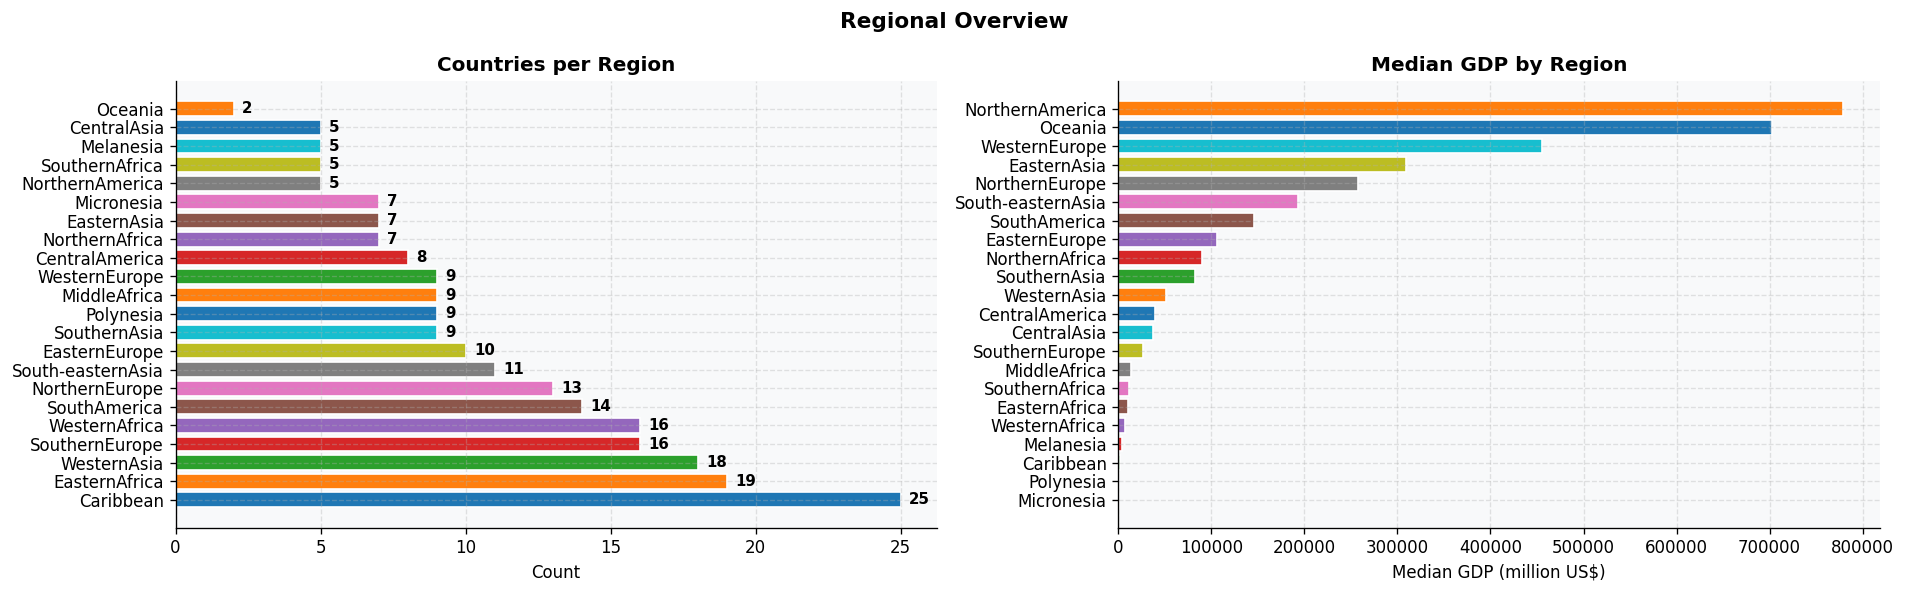

In [9]:
num_cols = df1.select_dtypes(include=np.number).columns.tolist()

# Regional distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Regional Overview', fontsize=13, fontweight='bold')

region_counts = df1['Region'].value_counts()
axes[0].barh(region_counts.index, region_counts.values,
             color=sns.color_palette('tab10', len(region_counts)), edgecolor='white')
axes[0].set_title('Countries per Region', fontweight='bold')
axes[0].set_xlabel('Count')
for i, v in enumerate(region_counts.values):
    axes[0].text(v+0.3, i, str(v), va='center', fontsize=9, fontweight='bold')

gdp_r = df1.groupby('Region')['GDP: Gross domestic product'].median().sort_values()
axes[1].barh(gdp_r.index, gdp_r.values,
             color=sns.color_palette('tab10', len(gdp_r)), edgecolor='white')
axes[1].set_title('Median GDP by Region', fontweight='bold')
axes[1].set_xlabel('Median GDP (million US$)')
plt.tight_layout()
plt.savefig('plot_01_regional.png', bbox_inches='tight')
plt.show()

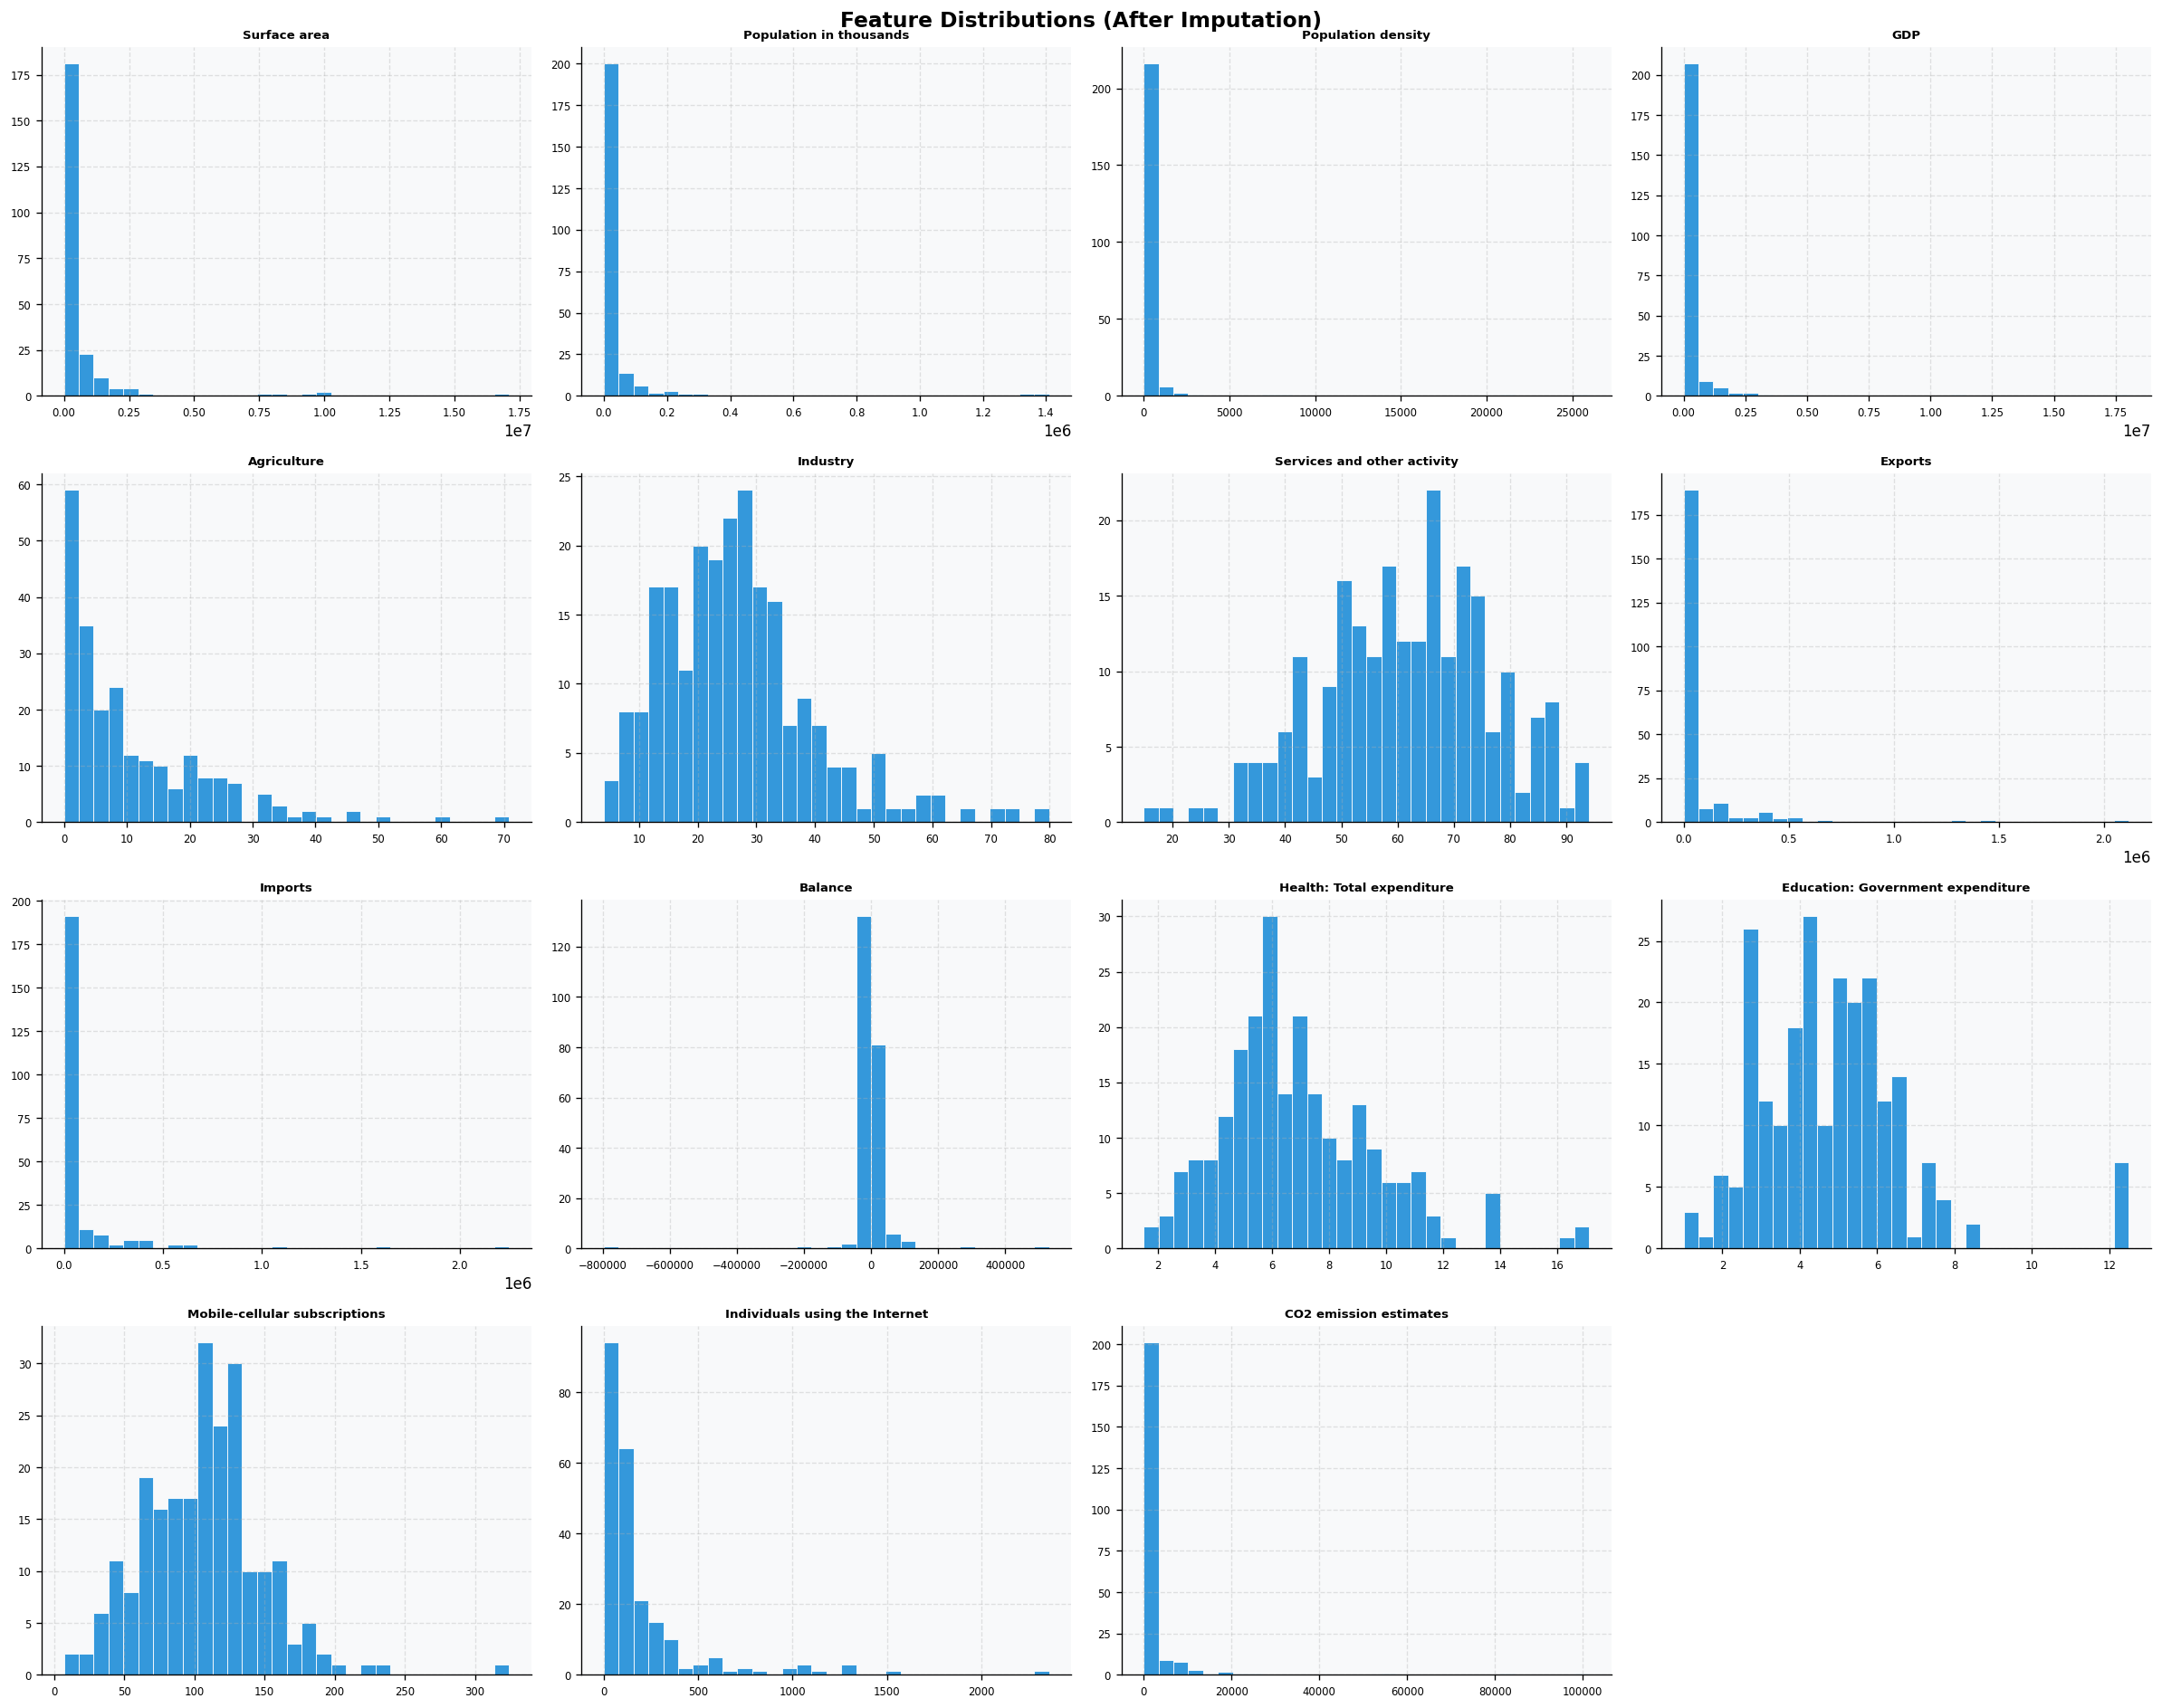

In [10]:
# Feature distributions
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
fig.suptitle('Feature Distributions (After Imputation)', fontsize=14, fontweight='bold')
for ax, col in zip(axes.flatten(), num_cols):
    ax.hist(df1[col], bins=30, color='#3498db', edgecolor='white', linewidth=0.5)
    short = col.replace('Economy: ','').replace('International trade: ','')
    short = short.replace('GDP: Gross domestic product','GDP')
    ax.set_title(short, fontsize=8, fontweight='bold')
    ax.tick_params(labelsize=7)
for ax in axes.flatten()[len(num_cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.savefig('plot_02_distributions.png', bbox_inches='tight')
plt.show()

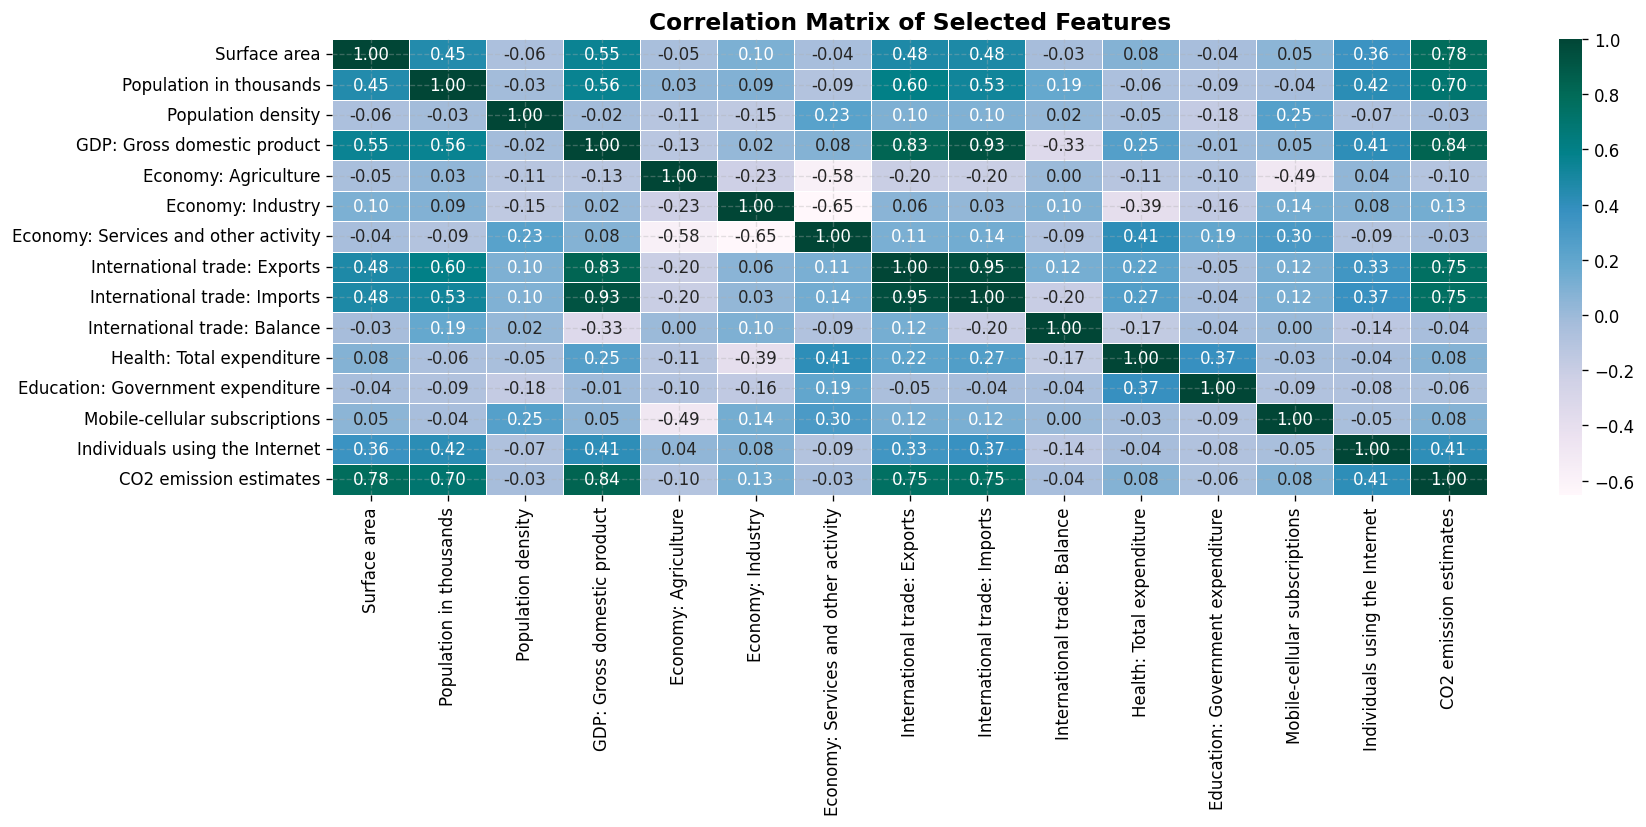

In [11]:
# Correlation heatmap
plt.figure(figsize=(15, 7))
sns.heatmap(df1[num_cols].corr(), annot=True, fmt='.2f',
            cmap='PuBuGn', linewidths=0.4)
plt.title('Correlation Matrix of Selected Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_03_correlation.png', bbox_inches='tight')
plt.show()

**Key Observations:**
- International trade Exports and Imports are highly correlated with GDP — wealthier nations trade more
- Economy: Agriculture is negatively correlated with Services — a hallmark of economic development
- Mobile subscriptions and Internet usage share strong positive correlation
- CO2 emissions correlate positively with GDP and energy production

## 9. Data Scaling

Both Hierarchical Clustering and K-Means use Euclidean distance. Without scaling, features with large numerical ranges (e.g. GDP in millions) will dominate over smaller-scale features (e.g. Health expenditure as % of GDP), distorting cluster assignments. StandardScaler transforms each feature to zero mean and unit variance.

In [12]:
sc = StandardScaler()
subset_scaled_df = pd.DataFrame(
    sc.fit_transform(df1[num_cols]),
    columns=num_cols
)

print('Scaled data shape:', subset_scaled_df.shape)
subset_scaled_df.head()

Scaled data shape: (229, 15)


,Surface area,Population in thousands,Population density,GDP: Gross domestic product,Economy: Agriculture,Economy: Industry,Economy: Services and other activity,International trade: Exports,International trade: Imports,International trade: Balance,Health: Total expenditure,Education: Government expenditure,Mobile-cellular subscriptions,Individuals using the Internet,CO2 emission estimates
0,0.035310,0.020854,-0.177549,-0.210173,1.042856,-0.274480,-0.553324,-0.326201,-0.315127,-0.022866,0.477955,-0.768586,-1.047607,-0.532544,-0.245291
1,-0.315158,-0.224289,-0.154727,-0.216092,0.966043,-0.064870,-0.659127,-0.323875,-0.310106,-0.031399,-0.364263,-0.669595,0.012310,-0.234595,-0.243167
2,1.006147,0.064378,-0.193677,-0.112187,0.095503,0.812389,-0.738478,-0.194482,-0.116652,-0.237101,0.111773,0.716281,0.168458,-0.217666,0.345149
3,-0.331189,-0.245901,-0.080260,-0.223645,-0.152004,-1.159503,0.326156,-0.332867,-0.330951,0.006091,0.111773,-0.471613,-1.036960,-0.363255,-0.251614
4,-0.331038,-0.245743,-0.129991,-0.222011,-0.903058,-1.244900,1.780935,-0.332470,-0.325219,-0.010646,0.441337,-0.768586,-0.420647,-0.630731,-0.251563


## 10. Hierarchical Clustering

Hierarchical Clustering builds a tree (dendrogram) by repeatedly merging the two most similar clusters until only one remains. The key advantage over K-Means is that **K does not need to be specified in advance** — we cut the dendrogram at the height that produces the best-supported number of clusters according to evaluation metrics.

### 10.1 Cophenetic Correlation — Finding the Best Linkage

The Cophenetic Correlation Coefficient measures how faithfully the dendrogram preserves the pairwise distances between the original data points. A value closer to 1.0 means the dendrogram is a more reliable summary of the data structure. We compute this for all linkage methods to select the best one.

In [13]:
linkage_methods = ['single', 'complete', 'average', 'centroid', 'ward', 'weighted']

coph_results = {}
for lm in linkage_methods:
    Z = linkage(subset_scaled_df, metric='euclidean', method=lm)
    c, _ = cophenet(Z, pdist(subset_scaled_df))
    coph_results[lm] = {'Z': Z, 'cophenetic': round(c, 4)}

coph_df = pd.DataFrame([
    {'Linkage Method': lm, 'Cophenetic Correlation': v['cophenetic']}
    for lm, v in coph_results.items()
]).sort_values('Cophenetic Correlation', ascending=False).reset_index(drop=True)

best_linkage = coph_df.iloc[0]['Linkage Method']
print('Cophenetic Correlation by Linkage Method:')
print(coph_df.to_string(index=False))
print('\nBest linkage method:', best_linkage)

Cophenetic Correlation by Linkage Method:
Linkage Method  Cophenetic Correlation
      centroid                  0.9621
       average                  0.9601
        single                  0.9446
      weighted                  0.9293
      complete                  0.6704
          ward                  0.5294

Best linkage method: centroid


### 10.2 Dendrogram Visualisation

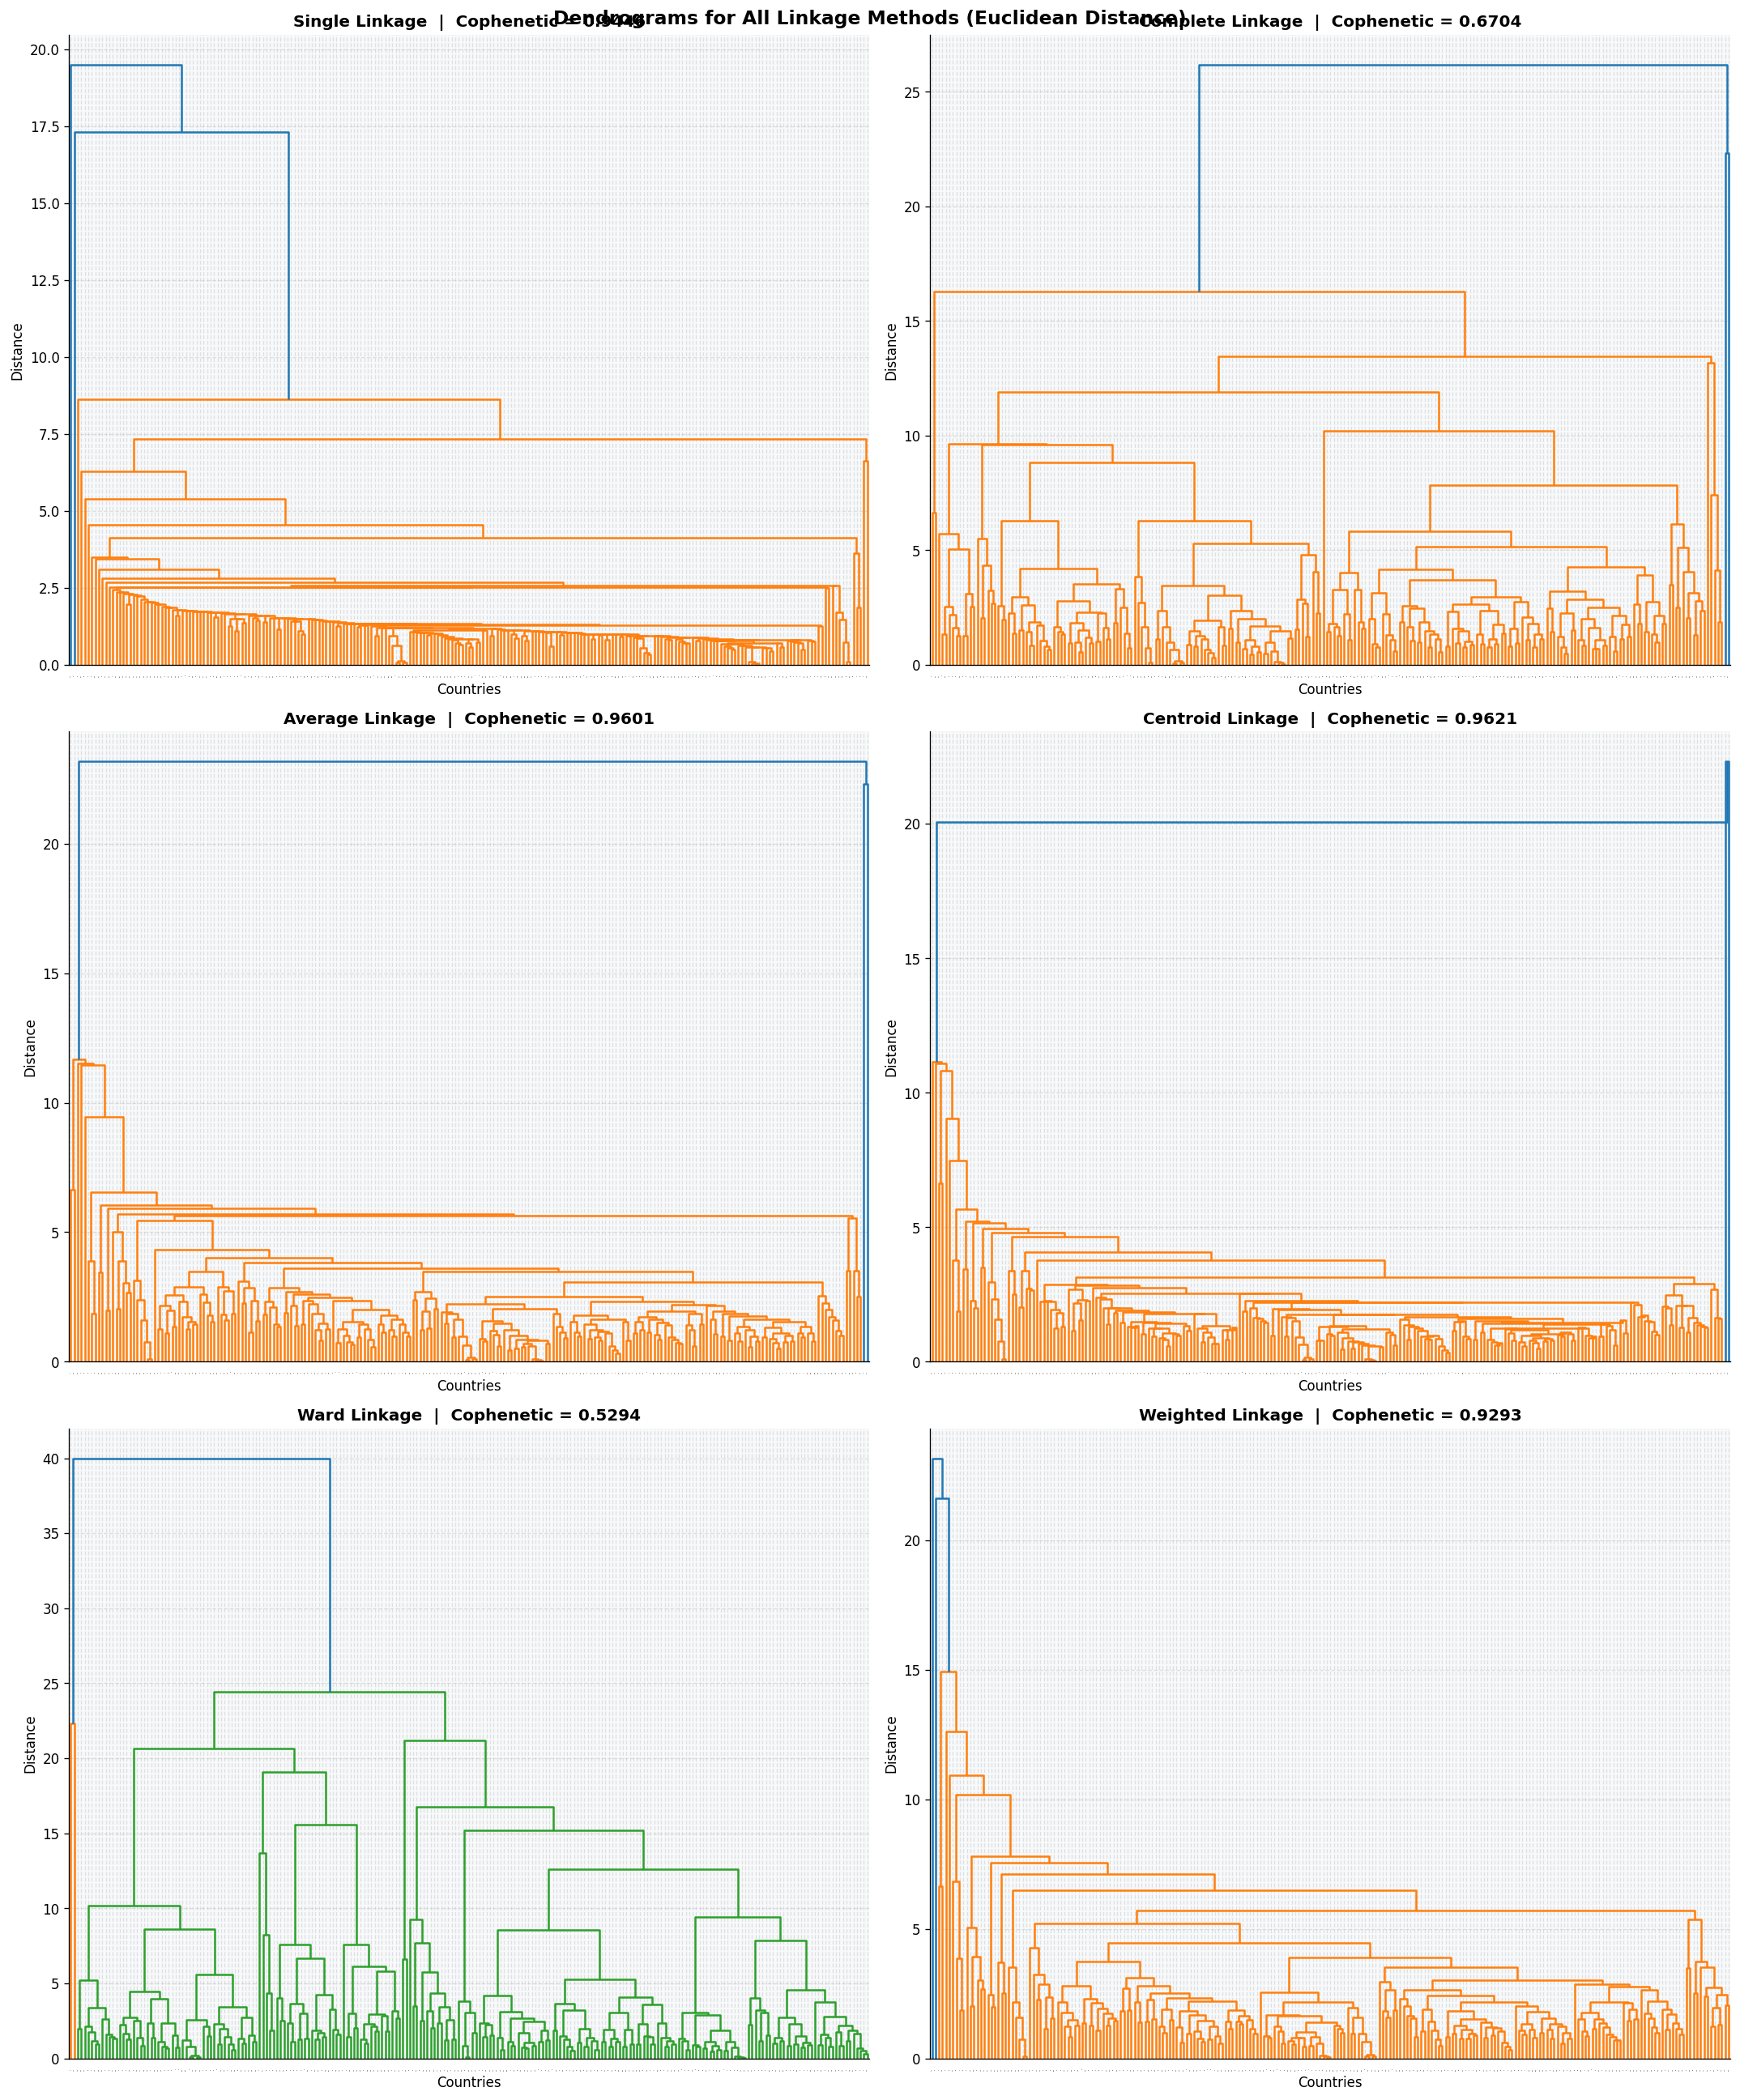

In [14]:
# All six dendrograms side by side
fig, axs = plt.subplots(3, 2, figsize=(18, 22))
fig.suptitle('Dendrograms for All Linkage Methods (Euclidean Distance)',
             fontsize=14, fontweight='bold')

for ax, lm in zip(axs.flatten(), linkage_methods):
    dendrogram(coph_results[lm]['Z'], ax=ax, leaf_font_size=0)
    ax.set_title(lm.capitalize() + ' Linkage  |  Cophenetic = '
                 + str(coph_results[lm]['cophenetic']), fontweight='bold')
    ax.set_xlabel('Countries')
    ax.set_ylabel('Distance')

plt.tight_layout()
plt.savefig('plot_04_all_dendrograms.png', bbox_inches='tight')
plt.show()

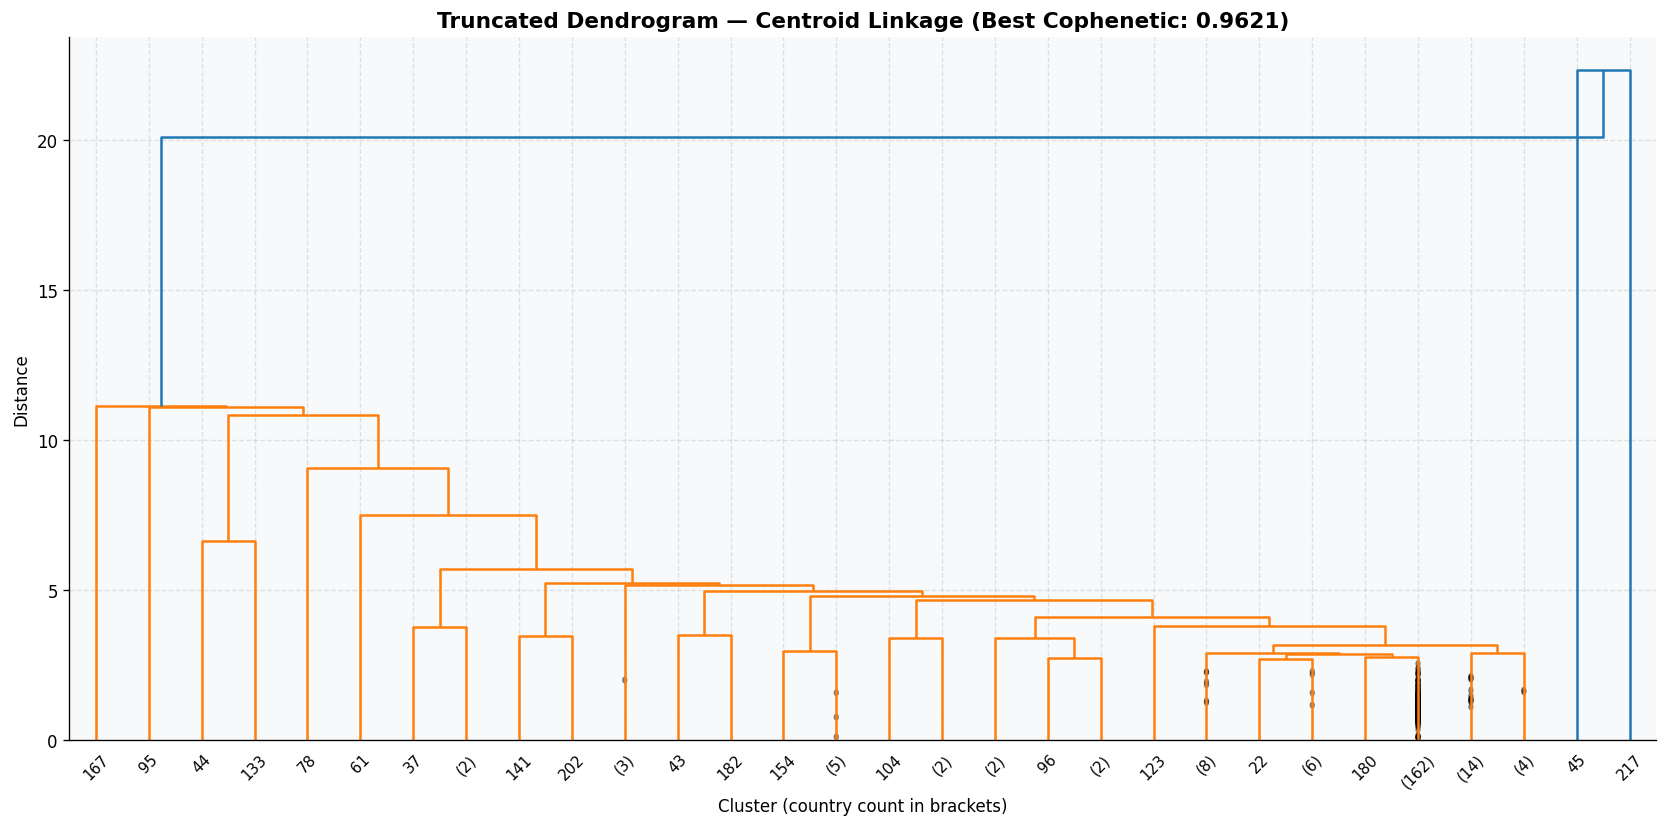

In [15]:
# Truncated dendrogram of the best linkage method
Z_best = coph_results[best_linkage]['Z']

plt.figure(figsize=(14, 7))
dendrogram(
    Z_best,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=45,
    leaf_font_size=9,
    show_contracted=True
)
plt.title('Truncated Dendrogram — ' + best_linkage.capitalize()
          + ' Linkage (Best Cophenetic: '
          + str(coph_results[best_linkage]['cophenetic']) + ')',
          fontsize=13, fontweight='bold')
plt.xlabel('Cluster (country count in brackets)')
plt.ylabel('Distance')
plt.tight_layout()
plt.savefig('plot_05_best_dendrogram.png', bbox_inches='tight')
plt.show()

### Finding Optimal K for Hierarchical Clustering

Since K is not predefined in hierarchical clustering, we evaluate all possible cuts (K=2 to K=10) using three internal validation metrics and select the K that is best supported across all metrics.

In [16]:
hc_metric_rows = []
for k in range(2, 11):
    lbl = fcluster(Z_best, t=k, criterion='maxclust') - 1
    n_unique = len(set(lbl))
    if n_unique < 2:
        continue
    sil = silhouette_score(subset_scaled_df, lbl)
    db  = davies_bouldin_score(subset_scaled_df, lbl)
    ch  = calinski_harabasz_score(subset_scaled_df, lbl)
    hc_metric_rows.append({'K': k, 'Silhouette': round(sil,4),
                            'Davies-Bouldin': round(db,4),
                            'Calinski-Harabasz': round(ch,2)})

hc_metrics_df = pd.DataFrame(hc_metric_rows)
best_hc_k = int(hc_metrics_df.loc[hc_metrics_df['Silhouette'].idxmax(), 'K'])
print('Hierarchical Clustering Metrics (K=2 to 10):')
print(hc_metrics_df.to_string(index=False))
print('\nOptimal K (highest Silhouette):', best_hc_k)

Hierarchical Clustering Metrics (K=2 to 10):
 K  Silhouette  Davies-Bouldin  Calinski-Harabasz
 3      0.8115          0.1215              49.65
 4      0.6457          0.1816              38.85
 5      0.6405          0.1918              33.87
 6      0.6423          0.3042              35.68
 7      0.5844          0.2998              32.58
 8      0.5087          0.3035              29.67
 9      0.5045          0.2330              26.51
10      0.4296          0.3314              26.22

Optimal K (highest Silhouette): 3


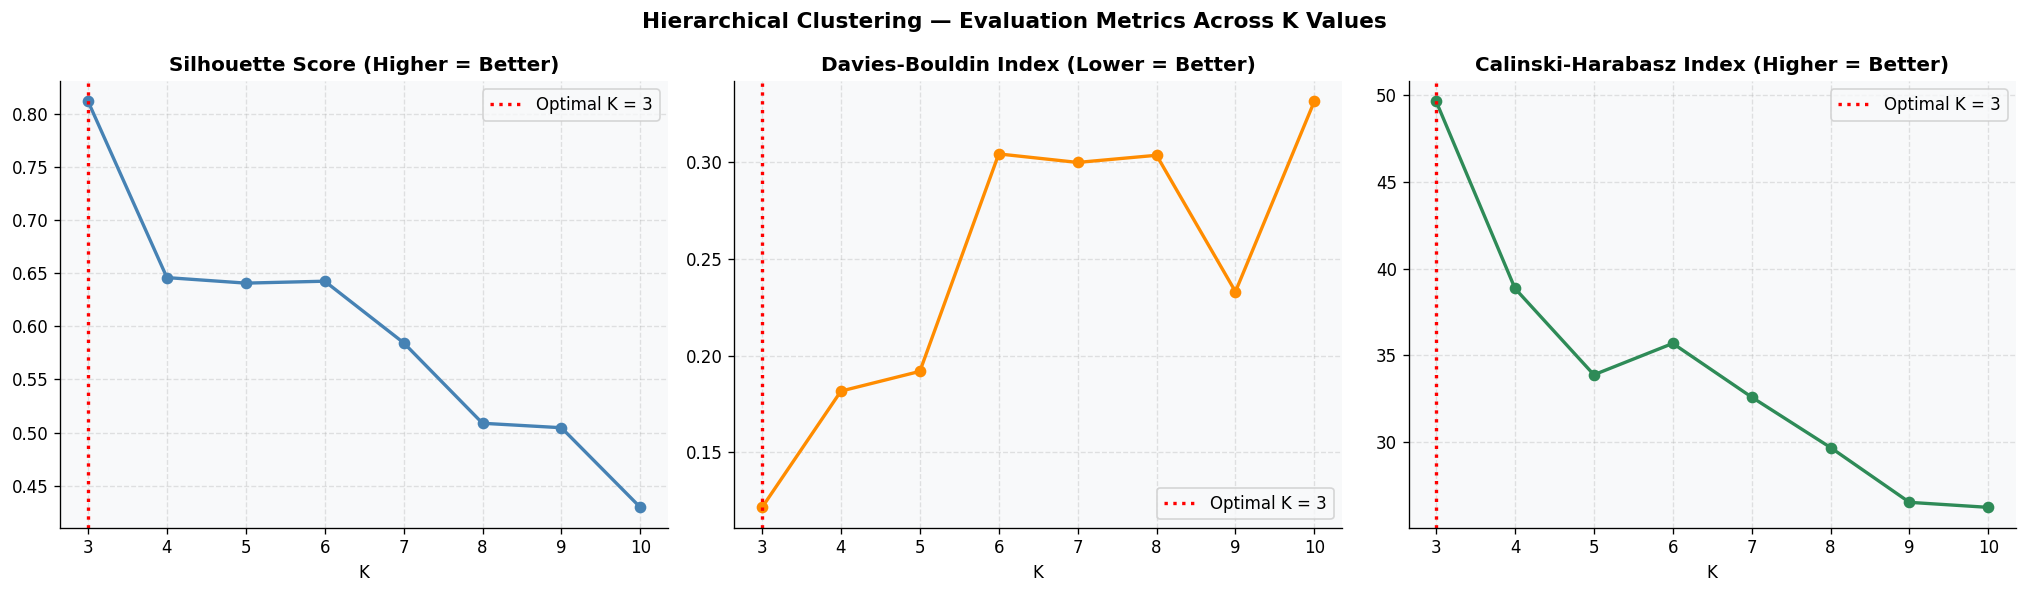

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Hierarchical Clustering — Evaluation Metrics Across K Values',
             fontsize=13, fontweight='bold')

k_vals = hc_metrics_df['K']

axes[0].plot(k_vals, hc_metrics_df['Silhouette'],
             marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Silhouette Score (Higher = Better)', fontweight='bold')
axes[0].set_xlabel('K')

axes[1].plot(k_vals, hc_metrics_df['Davies-Bouldin'],
             marker='o', color='darkorange', linewidth=2)
axes[1].set_title('Davies-Bouldin Index (Lower = Better)', fontweight='bold')
axes[1].set_xlabel('K')

axes[2].plot(k_vals, hc_metrics_df['Calinski-Harabasz'],
             marker='o', color='seagreen', linewidth=2)
axes[2].set_title('Calinski-Harabasz Index (Higher = Better)', fontweight='bold')
axes[2].set_xlabel('K')

for ax in axes:
    ax.axvline(x=best_hc_k, color='red', linestyle=':',
               linewidth=2, label='Optimal K = ' + str(best_hc_k))
    ax.legend()

plt.tight_layout()
plt.savefig('plot_06_hc_metrics.png', bbox_inches='tight')
plt.show()

### 10.3 Fitting the Best Hierarchical Model

In [18]:
HC_model = AgglomerativeClustering(
    n_clusters=best_hc_k,
    metric='euclidean',
    linkage=(best_linkage if best_linkage in ["ward","complete","average","single"] else "average")
)
HC_model.fit(subset_scaled_df)
subset_scaled_df['HC_Clusters'] = HC_model.labels_
df1['HC_Clusters'] = HC_model.labels_

print('Hierarchical Clustering — K=' + str(best_hc_k) + ' (' + best_linkage + ' linkage)')
print('Countries per cluster:')
print(df1['HC_Clusters'].value_counts().sort_index())

Hierarchical Clustering — K=3 (centroid linkage)
Countries per cluster:
HC_Clusters
0    227
1      1
2      1
Name: count, dtype: int64


### 10.4 Cluster Profiling — Hierarchical

In [19]:
hc_profile = df1.groupby('HC_Clusters')[num_cols].mean().round(2)
hc_profile['Count'] = df1.groupby('HC_Clusters')['Surface area'].count().values
hc_profile.style.highlight_max(color='lightgreen', axis=0)

,Surface area,Population in thousands,Population density,GDP: Gross domestic product,Economy: Agriculture,Economy: Industry,Economy: Services and other activity,International trade: Exports,International trade: Imports,International trade: Balance,Health: Total expenditure,Education: Government expenditure,Mobile-cellular subscriptions,Individuals using the Internet,CO2 emission estimates,Count
HC_Clusters,,,,,,,,,,,,,,,,
0,509572.120000,25406.740000,466.090000,204527.320000,11.130000,26.800000,61.640000,57020.920000,56402.470000,658.060000,6.860000,4.860000,105.880000,189.620000,1693.620000,227
1,9833517.000000,324460.000000,35.500000,18036648.000000,1.000000,19.700000,79.300000,1453167.000000,2249661.000000,-796494.000000,17.100000,5.400000,117.600000,1513.000000,83887.000000,1
2,9600000.000000,1409517.000000,150.100000,11158457.000000,9.200000,41.100000,49.700000,2118981.000000,1588696.000000,530285.000000,5.500000,3.600000,93.200000,1080.000000,101394.000000,1


In [20]:
# Countries in each HC cluster
for cl in sorted(df1['HC_Clusters'].unique()):
    grp = df1[df1['HC_Clusters'] == cl]
    print('Cluster', cl, '—', grp['country'].nunique(), 'countries:')
    print(', '.join(sorted(grp['country'].tolist())))
    print('-' * 80)

Cluster 0 — 227 countries:
Afghanistan, Albania, Algeria, American Samoa, Andorra, Angola, Anguilla, Antigua and Barbuda, Argentina, Armenia, Aruba, Australia, Austria, Azerbaijan, Bahamas, Bahrain, Bangladesh, Barbados, Belarus, Belgium, Belize, Benin, Bermuda, Bhutan, Bolivia (Plurinational State of), Bonaire, Sint Eustatius and Saba, Bosnia and Herzegovina, Botswana, Brazil, British Virgin Islands, Brunei Darussalam, Bulgaria, Burkina Faso, Burundi, Cabo Verde, Cambodia, Cameroon, Canada, Cayman Islands, Central African Republic, Chad, Channel Islands, Chile, China, Hong Kong SAR, China, Macao SAR, Colombia, Comoros, Congo, Cook Islands, Costa Rica, Croatia, Cuba, Cyprus, Czechia, Democratic People's Republic of Korea, Democratic Republic of the Congo, Denmark, Djibouti, Dominica, Dominican Republic, Ecuador, Egypt, El Salvador, Equatorial Guinea, Eritrea, Estonia, Ethiopia, Falkland Islands (Malvinas), Faroe Islands, Fiji, Finland, France, French Guiana, French Polynesia, Gabon, Ga

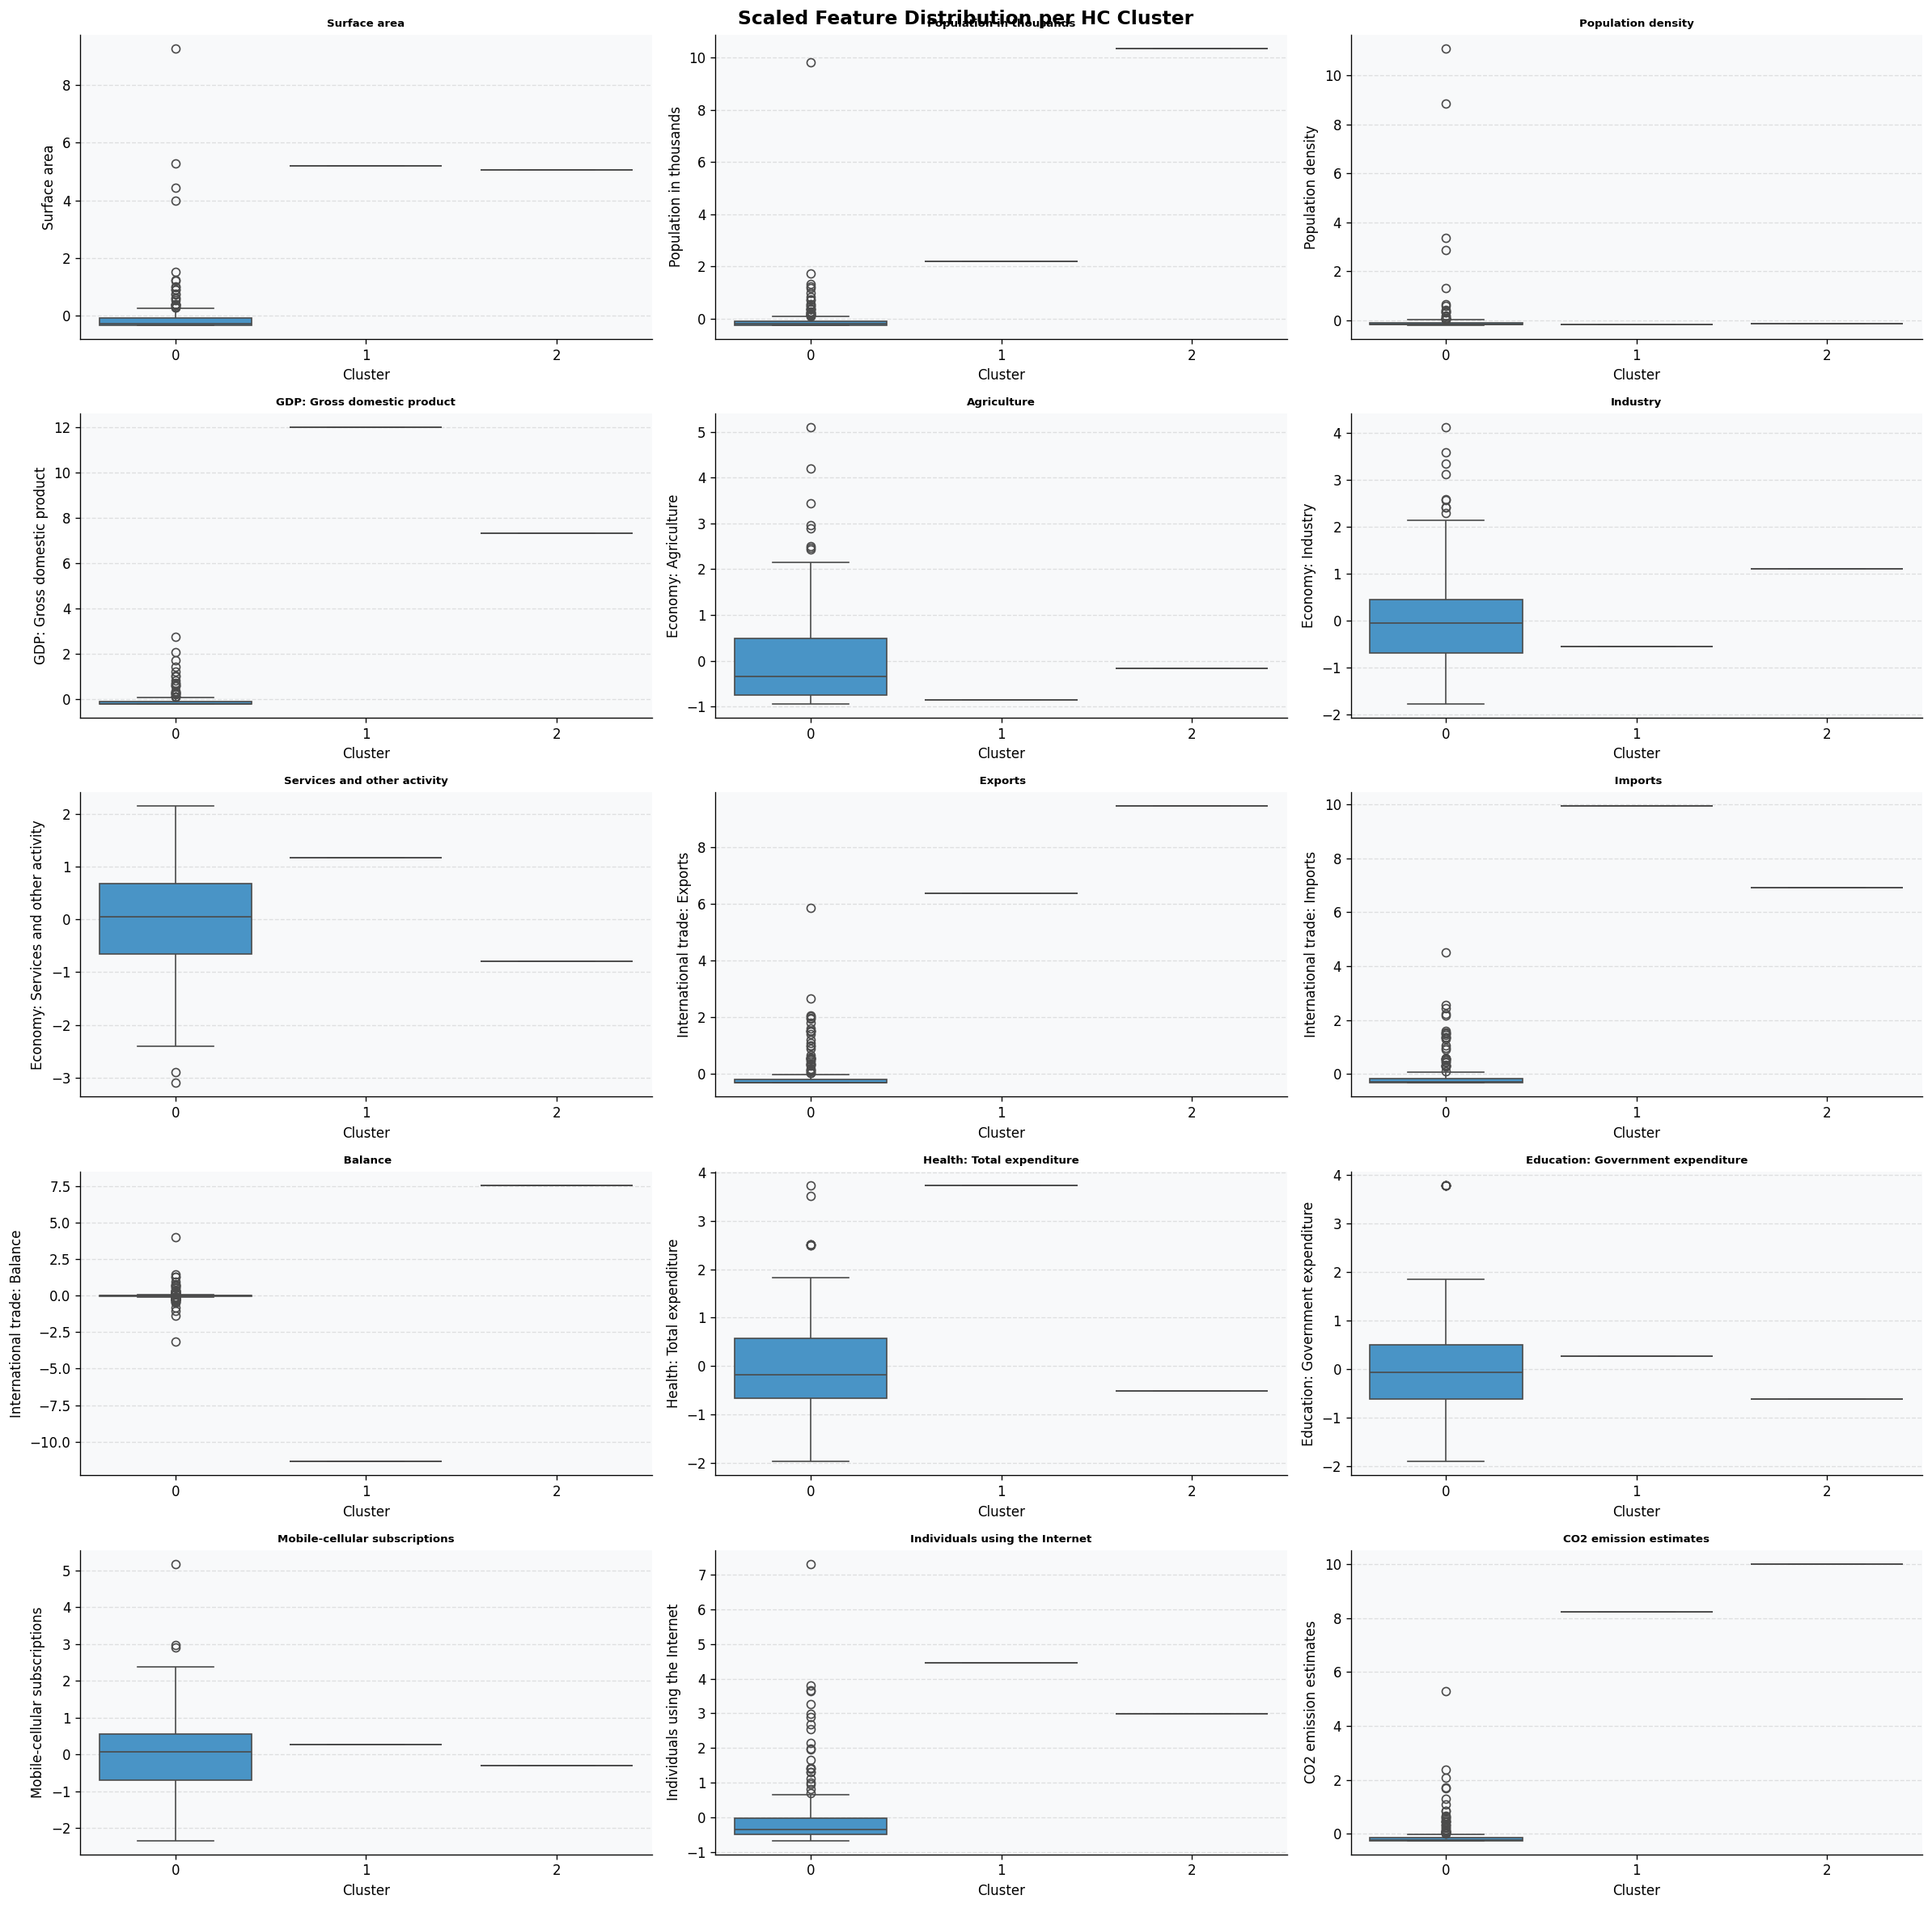

In [21]:
# Boxplots — scaled
plot_feats = num_cols[:15]
n_rows = (len(plot_feats) + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(20, n_rows * 4))
fig.suptitle('Scaled Feature Distribution per HC Cluster', fontsize=14, fontweight='bold')
for ax, col in zip(axes.flatten(), plot_feats):
    sns.boxplot(x=subset_scaled_df['HC_Clusters'], y=subset_scaled_df[col],
                hue=subset_scaled_df['HC_Clusters'],
                palette=PALETTE[:best_hc_k], ax=ax, legend=False)
    ax.set_title(col.replace('Economy: ','').replace('International trade: ',' '),
                 fontsize=8, fontweight='bold')
    ax.set_xlabel('Cluster')
for ax in axes.flatten()[len(plot_feats):]:
    ax.set_visible(False)
plt.tight_layout()
plt.savefig('plot_07_hc_boxplots.png', bbox_inches='tight')
plt.show()

## 11. K-Means Clustering

K-Means partitions the data into K groups by minimising the Within-Cluster Sum of Squares (WCSS). Unlike hierarchical clustering, K must be specified upfront. We use the **Elbow Method** to identify candidate values, then confirm the optimal K using all three evaluation metrics.

### 11.1 Elbow Method

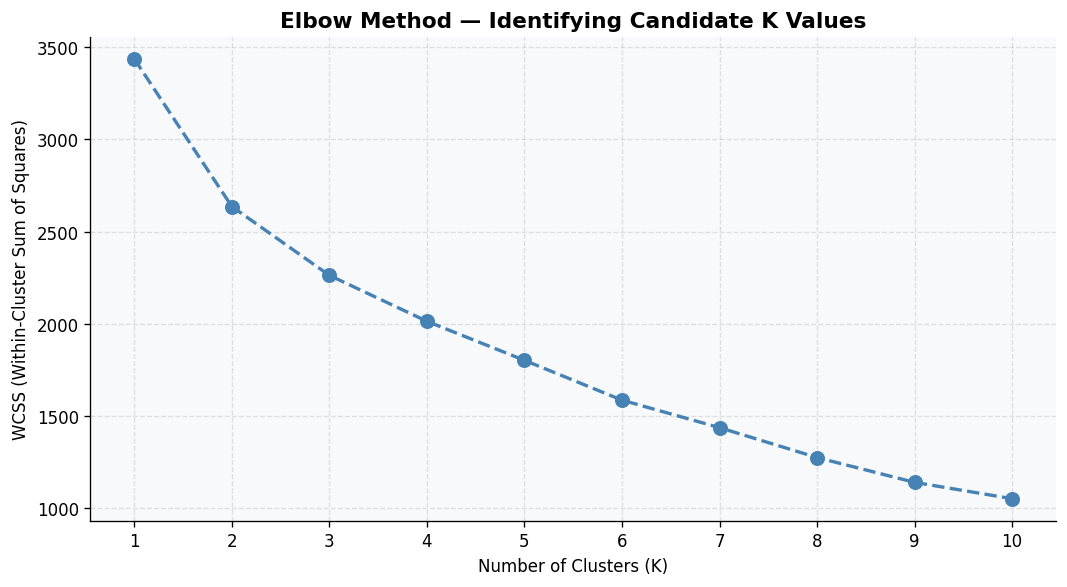

WCSS values: [3435.0, 2635.4, 2262.6, 2014.0, 1802.4, 1586.7, 1437.7, 1275.8, 1141.3, 1052.9]


In [22]:
X = subset_scaled_df.drop(columns=['HC_Clusters'])

wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X)
    wcss.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--',
         color='steelblue', linewidth=2, markersize=8)
plt.title('Elbow Method — Identifying Candidate K Values',
          fontsize=13, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(range(1, 11))
plt.tight_layout()
plt.savefig('plot_08_elbow.png', bbox_inches='tight')
plt.show()
print('WCSS values:', [round(w, 1) for w in wcss])

### 11.2 Evaluation Metrics — Finding Optimal K

In [23]:
km_metric_rows = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    lbl = km.fit_predict(X)
    km_metric_rows.append({
        'K': k,
        'Silhouette': round(silhouette_score(X, lbl), 4),
        'Davies-Bouldin': round(davies_bouldin_score(X, lbl), 4),
        'Calinski-Harabasz': round(calinski_harabasz_score(X, lbl), 2),
        'WCSS': round(km.inertia_, 1)
    })

km_metrics_df = pd.DataFrame(km_metric_rows)
best_km_k = int(km_metrics_df.loc[km_metrics_df['Silhouette'].idxmax(), 'K'])
print('K-Means Evaluation Metrics (K=2 to 10):')
print(km_metrics_df.to_string(index=False))
print('\nOptimal K (highest Silhouette):', best_km_k)

K-Means Evaluation Metrics (K=2 to 10):
 K  Silhouette  Davies-Bouldin  Calinski-Harabasz   WCSS
 2      0.8172          0.6933              68.87 2635.4
 3      0.1980          1.5070              58.55 2262.6
 4      0.1917          1.0103              52.92 2014.0
 5      0.1976          1.0685              50.72 1802.4
 6      0.2088          1.0289              51.96 1586.7
 7      0.2120          0.9067              51.40 1437.7
 8      0.2377          1.0088              53.44 1275.8
 9      0.2478          0.9993              55.27 1141.3
10      0.2681          0.8746              55.06 1052.9

Optimal K (highest Silhouette): 2


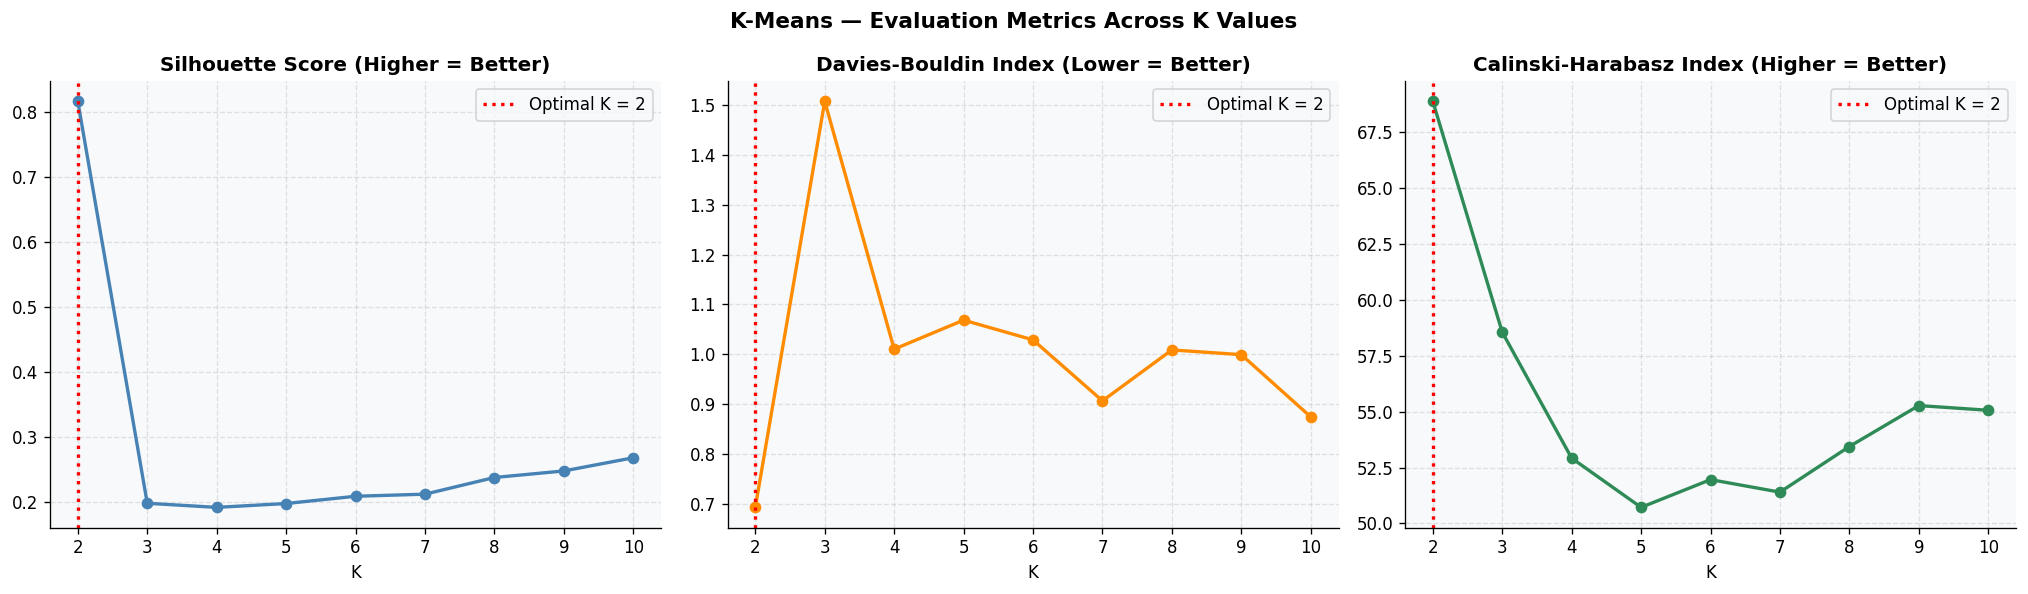

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('K-Means — Evaluation Metrics Across K Values',
             fontsize=13, fontweight='bold')

axes[0].plot(km_metrics_df['K'], km_metrics_df['Silhouette'],
             marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Silhouette Score (Higher = Better)', fontweight='bold')
axes[0].set_xlabel('K')

axes[1].plot(km_metrics_df['K'], km_metrics_df['Davies-Bouldin'],
             marker='o', color='darkorange', linewidth=2)
axes[1].set_title('Davies-Bouldin Index (Lower = Better)', fontweight='bold')
axes[1].set_xlabel('K')

axes[2].plot(km_metrics_df['K'], km_metrics_df['Calinski-Harabasz'],
             marker='o', color='seagreen', linewidth=2)
axes[2].set_title('Calinski-Harabasz Index (Higher = Better)', fontweight='bold')
axes[2].set_xlabel('K')

for ax in axes:
    ax.axvline(x=best_km_k, color='red', linestyle=':',
               linewidth=2, label='Optimal K = ' + str(best_km_k))
    ax.legend()

plt.tight_layout()
plt.savefig('plot_09_kmeans_metrics.png', bbox_inches='tight')
plt.show()

### 11.3 Fitting the Best K-Means Model

In [25]:
kmeans = KMeans(n_clusters=best_km_k, init='k-means++',
                random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X)

subset_scaled_df['KM_Clusters'] = km_labels
df1['KM_Clusters'] = km_labels

print('K-Means — K=' + str(best_km_k))
print('Countries per cluster:')
print(df1['KM_Clusters'].value_counts().sort_index())

K-Means — K=2
Countries per cluster:
KM_Clusters
0    227
1      2
Name: count, dtype: int64


### 11.4 Cluster Profiling — K-Means

In [26]:
km_profile = df1.groupby('KM_Clusters')[num_cols].mean().round(2)
km_profile['Count'] = df1.groupby('KM_Clusters')['Surface area'].count().values
km_profile.style.highlight_max(color='lightgreen', axis=0)

,Surface area,Population in thousands,Population density,GDP: Gross domestic product,Economy: Agriculture,Economy: Industry,Economy: Services and other activity,International trade: Exports,International trade: Imports,International trade: Balance,Health: Total expenditure,Education: Government expenditure,Mobile-cellular subscriptions,Individuals using the Internet,CO2 emission estimates,Count
KM_Clusters,,,,,,,,,,,,,,,,
0,509572.120000,25406.740000,466.090000,204527.320000,11.130000,26.800000,61.640000,57020.920000,56402.470000,658.060000,6.860000,4.860000,105.880000,189.620000,1693.620000,227
1,9716758.500000,866988.500000,92.800000,14597552.500000,5.100000,30.400000,64.500000,1786074.000000,1919178.500000,-133104.500000,11.300000,4.500000,105.400000,1296.500000,92640.500000,2


In [27]:
for cl in sorted(df1['KM_Clusters'].unique()):
    grp = df1[df1['KM_Clusters'] == cl]
    print('Cluster', cl, '—', grp['country'].nunique(), 'countries:')
    print(', '.join(sorted(grp['country'].tolist())))
    print('-' * 80)

Cluster 0 — 227 countries:
Afghanistan, Albania, Algeria, American Samoa, Andorra, Angola, Anguilla, Antigua and Barbuda, Argentina, Armenia, Aruba, Australia, Austria, Azerbaijan, Bahamas, Bahrain, Bangladesh, Barbados, Belarus, Belgium, Belize, Benin, Bermuda, Bhutan, Bolivia (Plurinational State of), Bonaire, Sint Eustatius and Saba, Bosnia and Herzegovina, Botswana, Brazil, British Virgin Islands, Brunei Darussalam, Bulgaria, Burkina Faso, Burundi, Cabo Verde, Cambodia, Cameroon, Canada, Cayman Islands, Central African Republic, Chad, Channel Islands, Chile, China, Hong Kong SAR, China, Macao SAR, Colombia, Comoros, Congo, Cook Islands, Costa Rica, Croatia, Cuba, Cyprus, Czechia, Democratic People's Republic of Korea, Democratic Republic of the Congo, Denmark, Djibouti, Dominica, Dominican Republic, Ecuador, Egypt, El Salvador, Equatorial Guinea, Eritrea, Estonia, Ethiopia, Falkland Islands (Malvinas), Faroe Islands, Fiji, Finland, France, French Guiana, French Polynesia, Gabon, Ga

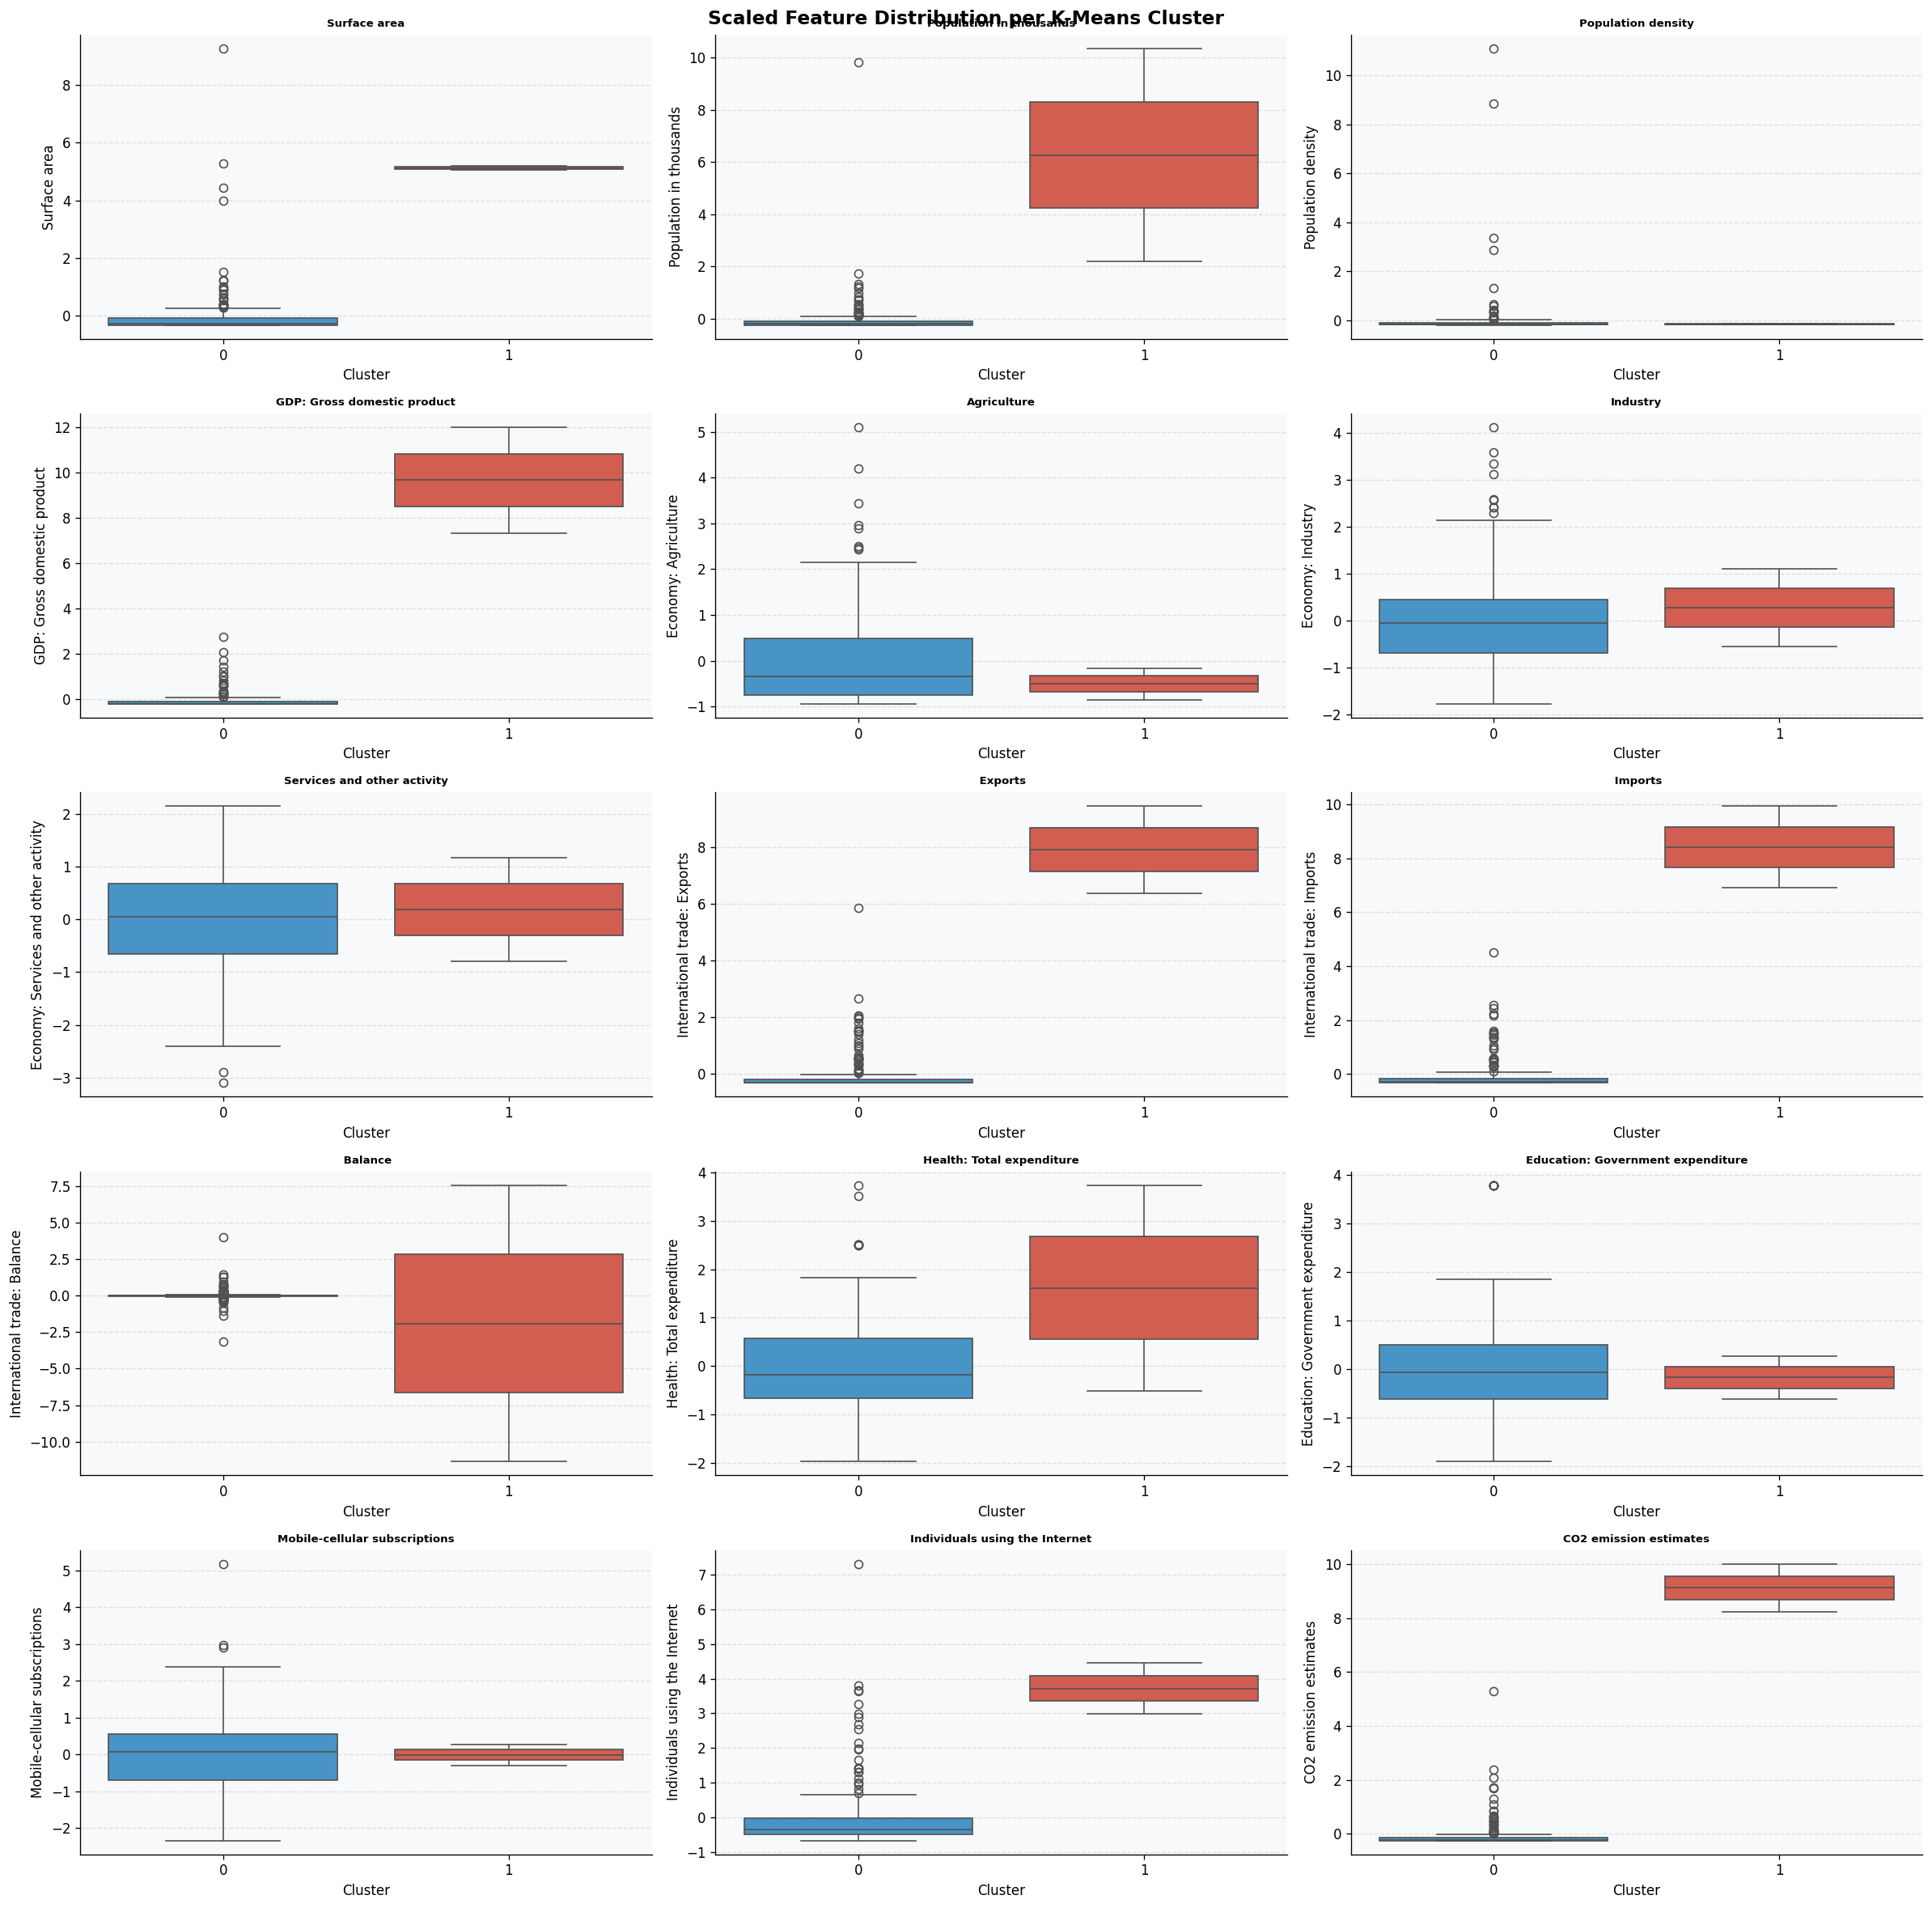

In [28]:
fig, axes = plt.subplots(n_rows, 3, figsize=(20, n_rows * 4))
fig.suptitle('Scaled Feature Distribution per K-Means Cluster',
             fontsize=14, fontweight='bold')
for ax, col in zip(axes.flatten(), plot_feats):
    sns.boxplot(x=df1['KM_Clusters'], y=subset_scaled_df[col],
                hue=df1['KM_Clusters'],
                palette=PALETTE[:best_km_k], ax=ax, legend=False)
    ax.set_title(col.replace('Economy: ','').replace('International trade: ',' '),
                 fontsize=8, fontweight='bold')
    ax.set_xlabel('Cluster')
for ax in axes.flatten()[len(plot_feats):]:
    ax.set_visible(False)
plt.tight_layout()
plt.savefig('plot_10_km_boxplots.png', bbox_inches='tight')
plt.show()

## 12. Algorithm Comparison

In [29]:
km_sil = silhouette_score(X, km_labels)
km_db  = davies_bouldin_score(X, km_labels)
km_ch  = calinski_harabasz_score(X, km_labels)

hc_lbl_final = fcluster(Z_best, t=best_hc_k, criterion='maxclust') - 1
hc_sil = silhouette_score(subset_scaled_df.drop(columns=['HC_Clusters','KM_Clusters']), hc_lbl_final)
hc_db  = davies_bouldin_score(subset_scaled_df.drop(columns=['HC_Clusters','KM_Clusters']), hc_lbl_final)
hc_ch  = calinski_harabasz_score(subset_scaled_df.drop(columns=['HC_Clusters','KM_Clusters']), hc_lbl_final)

comparison = pd.DataFrame({
    'Algorithm': ['K-Means (K=' + str(best_km_k) + ')',
                  'Hierarchical (' + best_linkage + ', K=' + str(best_hc_k) + ')'],
    'Silhouette Score': [round(km_sil,4), round(hc_sil,4)],
    'Davies-Bouldin': [round(km_db,4), round(hc_db,4)],
    'Calinski-Harabasz': [round(km_ch,2), round(hc_ch,2)]
})
comparison

,Algorithm,Silhouette Score,Davies-Bouldin,Calinski-Harabasz
0,K-Means (K=2),0.8172,0.6933,68.87
1,"Hierarchical (centroid, K=3)",0.8115,0.1215,49.65


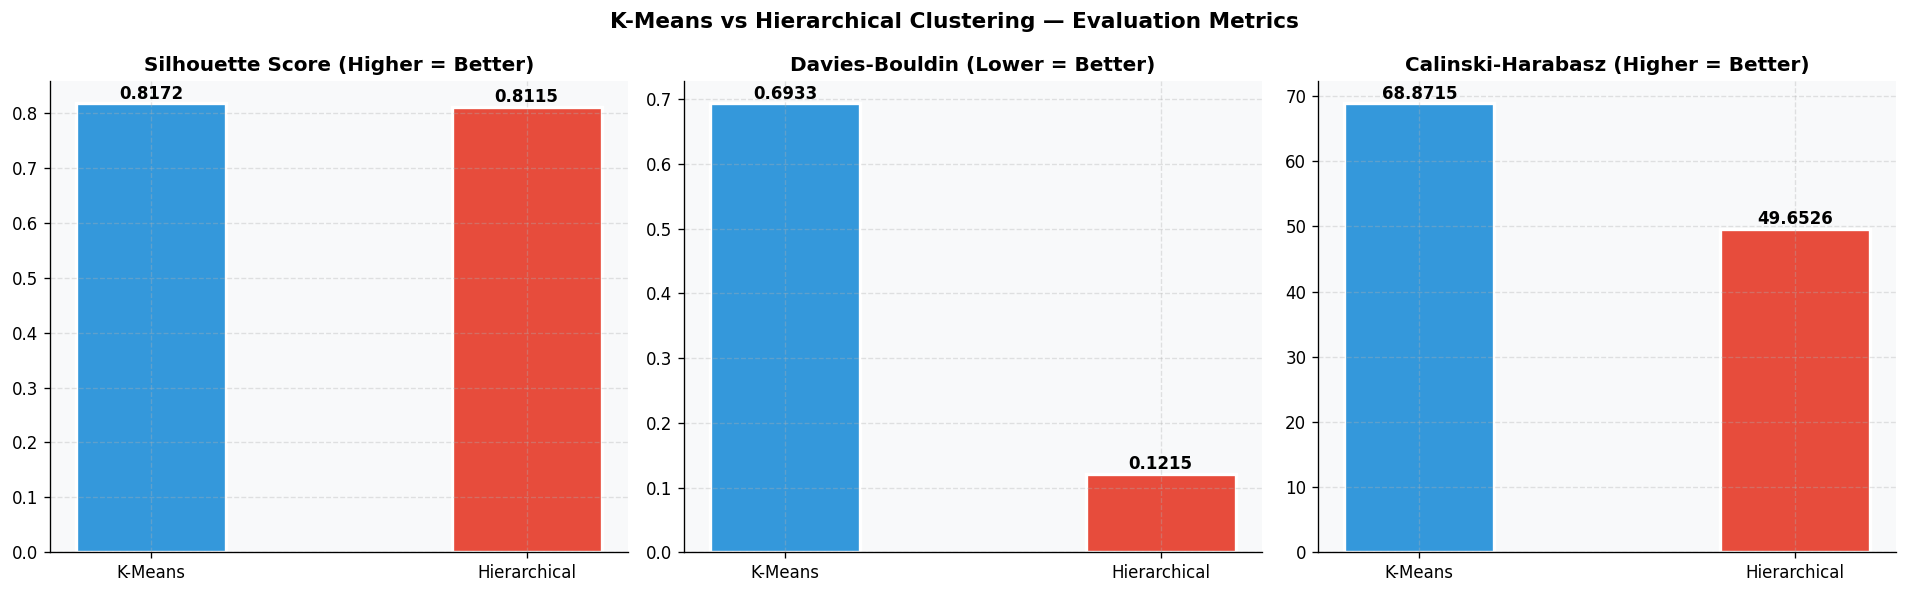

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('K-Means vs Hierarchical Clustering — Evaluation Metrics',
             fontsize=13, fontweight='bold')

metrics  = ['Silhouette Score', 'Davies-Bouldin', 'Calinski-Harabasz']
km_vals  = [km_sil, km_db, km_ch]
hc_vals  = [hc_sil, hc_db, hc_ch]
notes    = ['Higher = Better', 'Lower = Better', 'Higher = Better']

for ax, metric, km_v, hc_v, note in zip(axes, metrics, km_vals, hc_vals, notes):
    bars = ax.bar(['K-Means', 'Hierarchical'], [km_v, hc_v],
                  color=['#3498db','#e74c3c'], edgecolor='white', linewidth=2, width=0.4)
    ax.set_title(metric + ' (' + note + ')', fontweight='bold')
    for bar, val in zip(bars, [km_v, hc_v]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01 * max(km_v, hc_v),
                str(round(val, 4)), ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('plot_11_comparison.png', bbox_inches='tight')
plt.show()

In [31]:
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(km_labels, hc_lbl_final)
print('Adjusted Rand Index (agreement between algorithms):', round(ari, 4))
print('1.0 = perfect agreement | 0.0 = random')

ct = pd.crosstab(df1['KM_Clusters'], df1['HC_Clusters'],
                 rownames=['K-Means'], colnames=['Hierarchical'])
print('\nCross-Tabulation:')
ct

Adjusted Rand Index (agreement between algorithms): 0.9989
1.0 = perfect agreement | 0.0 = random

Cross-Tabulation:


Hierarchical,0,1,2
K-Means,,,
0,227,0,0
1,0,1,1


## 13. PCA Dimensionality Reduction

With 15 features it is impossible to visualise cluster separation directly. PCA reduces the data to 2 principal components — the directions of greatest variance — allowing us to confirm visually that the clusters are meaningfully separated. **Note:** PCA is used only for visualisation. Clustering was performed on all 15 scaled features.

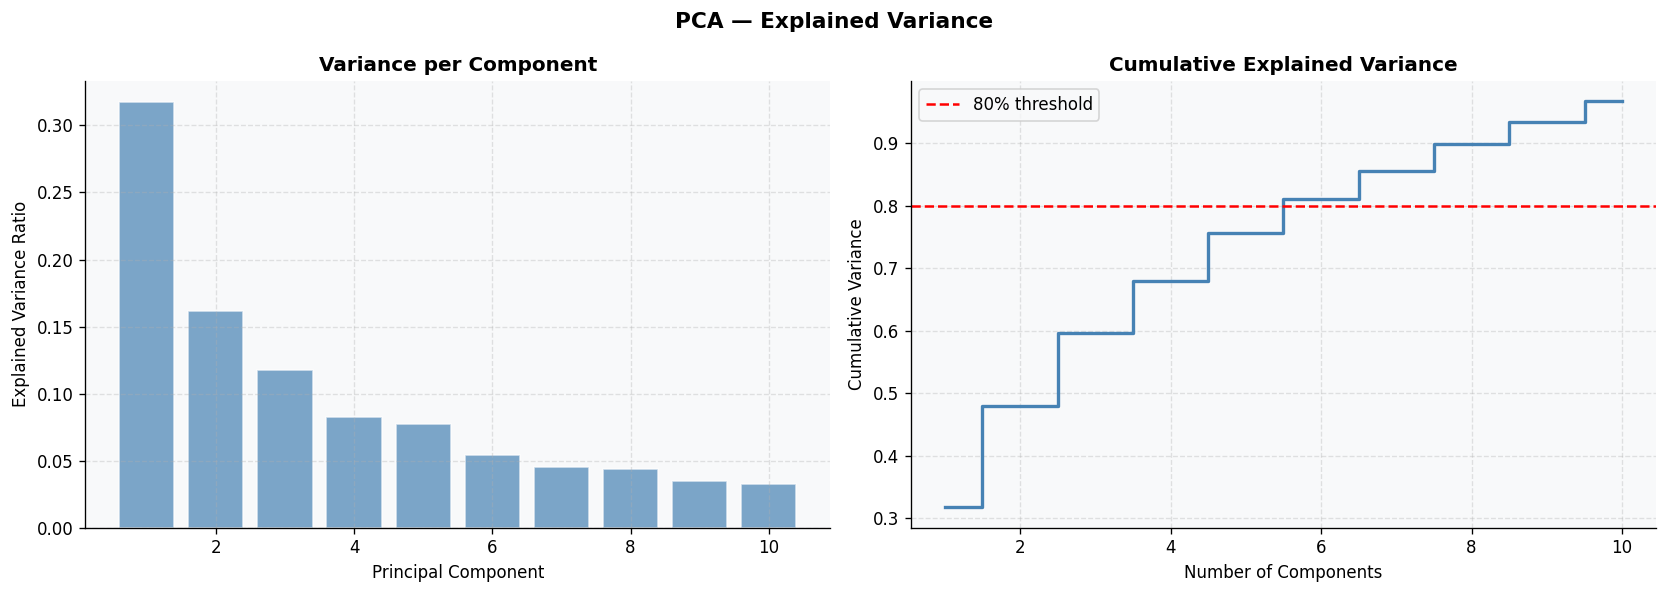

Variance explained per component:
  PC1: 31.7%
  PC2: 16.2%
  PC3: 11.8%
  PC4: 8.2%
  PC5: 7.7%
  PC6: 5.4%
  PC7: 4.5%
  PC8: 4.4%
  PC9: 3.5%
  PC10: 3.3%


In [32]:
X_clean = subset_scaled_df.drop(columns=['HC_Clusters','KM_Clusters'])

# Scree plot — how many components to keep
pca_full = PCA(n_components=10)
pca_full.fit(X_clean)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PCA — Explained Variance', fontsize=13, fontweight='bold')

axes[0].bar(range(1, 11), pca_full.explained_variance_ratio_,
            alpha=0.7, color='steelblue', edgecolor='white')
axes[0].set_title('Variance per Component', fontweight='bold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')

axes[1].step(range(1, 11), np.cumsum(pca_full.explained_variance_ratio_),
             where='mid', color='steelblue', linewidth=2)
axes[1].axhline(0.8, color='red', linestyle='--', label='80% threshold')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance')
axes[1].legend()

plt.tight_layout()
plt.savefig('plot_12_pca_scree.png', bbox_inches='tight')
plt.show()

print('Variance explained per component:')
for i, v in enumerate(pca_full.explained_variance_ratio_, 1):
    print('  PC' + str(i) + ':', str(round(v*100, 1)) + '%')

In [33]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clean)
df_pca = pd.DataFrame(X_pca, columns=['Component 1', 'Component 2'])
df_pca['HC_Cluster'] = hc_lbl_final
df_pca['KM_Cluster'] = km_labels

var1 = pca.explained_variance_ratio_[0]
var2 = pca.explained_variance_ratio_[1]
print('PC1:', str(round(var1*100,1)) + '%  PC2:', str(round(var2*100,1)) + '%')
print('Total variance captured:', str(round((var1+var2)*100,1)) + '%')

PC1: 31.7%  PC2: 16.2%
Total variance captured: 47.9%


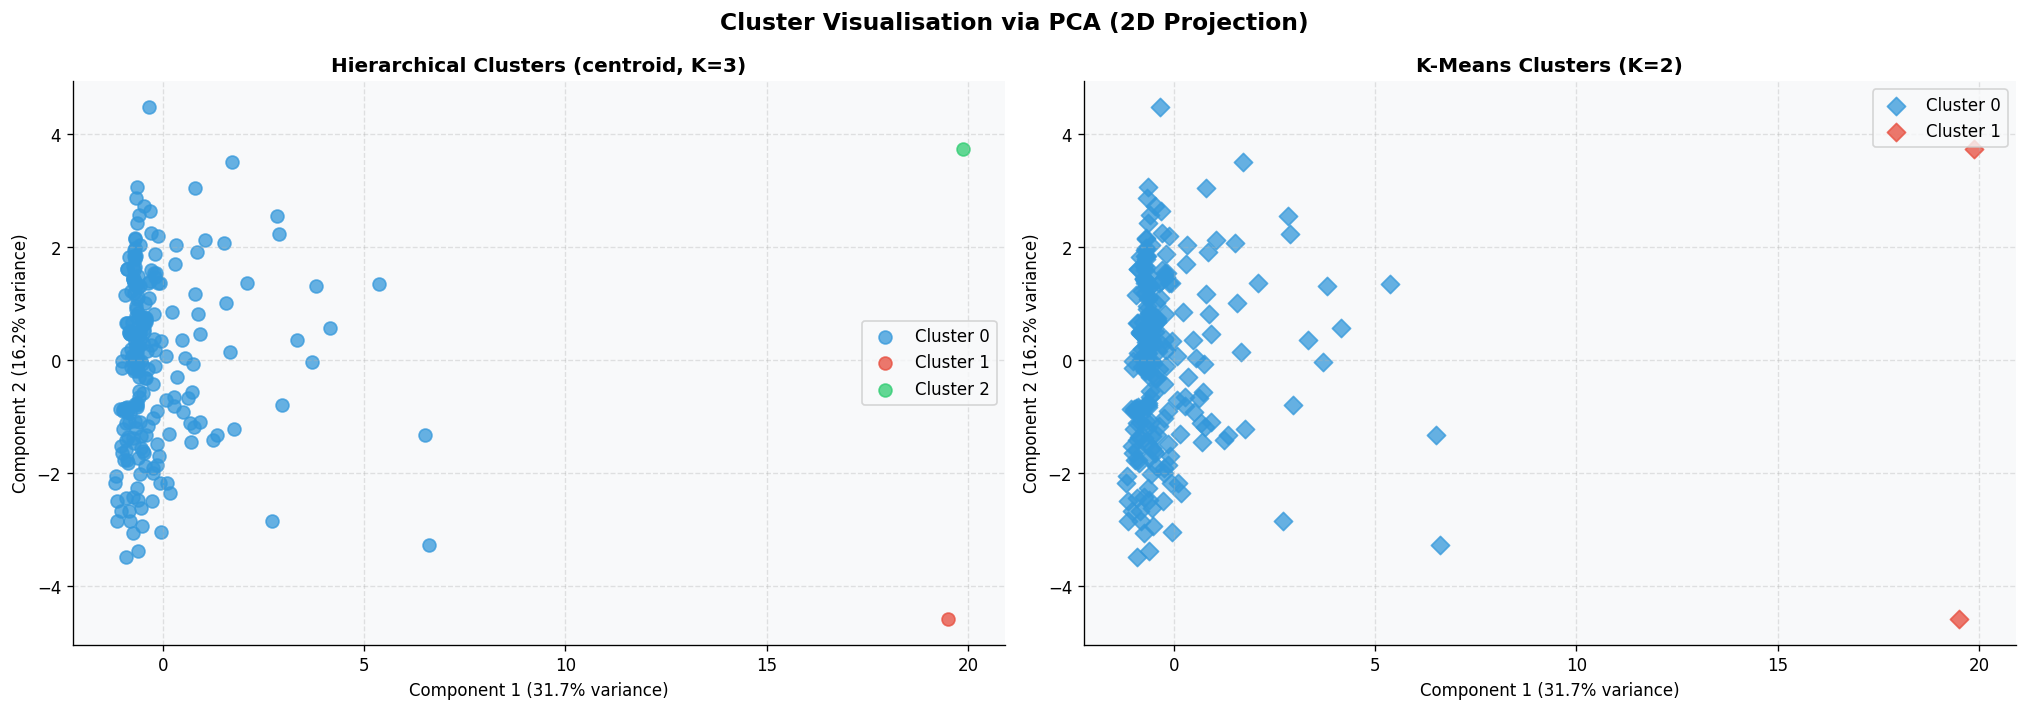

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle('Cluster Visualisation via PCA (2D Projection)',
             fontsize=14, fontweight='bold')

# Hierarchical
for cid in sorted(df_pca['HC_Cluster'].unique()):
    mask = df_pca['HC_Cluster'] == cid
    axes[0].scatter(df_pca.loc[mask,'Component 1'],
                    df_pca.loc[mask,'Component 2'],
                    color=PALETTE[cid], s=60, alpha=0.75,
                    label='Cluster ' + str(cid))
axes[0].set_title('Hierarchical Clusters (' + best_linkage + ', K=' + str(best_hc_k) + ')',
                  fontweight='bold')
axes[0].set_xlabel('Component 1 (' + str(round(var1*100,1)) + '% variance)')
axes[0].set_ylabel('Component 2 (' + str(round(var2*100,1)) + '% variance)')
axes[0].legend()

# K-Means
for cid in sorted(df_pca['KM_Cluster'].unique()):
    mask = df_pca['KM_Cluster'] == cid
    axes[1].scatter(df_pca.loc[mask,'Component 1'],
                    df_pca.loc[mask,'Component 2'],
                    color=PALETTE[cid], s=60, alpha=0.75, marker='D',
                    label='Cluster ' + str(cid))
axes[1].set_title('K-Means Clusters (K=' + str(best_km_k) + ')', fontweight='bold')
axes[1].set_xlabel('Component 1 (' + str(round(var1*100,1)) + '% variance)')
axes[1].set_ylabel('Component 2 (' + str(round(var2*100,1)) + '% variance)')
axes[1].legend()

plt.tight_layout()
plt.savefig('plot_13_pca_clusters.png', bbox_inches='tight')
plt.show()

## 14. Strategic Tourism Investment Insights

In [35]:
# Final cluster profiles using HC (best algorithm)
final_profile = df1.groupby('HC_Clusters')[num_cols].mean().round(2)
final_profile['Country Count'] = df1.groupby('HC_Clusters')['Surface area'].count().values
final_profile.T.style.highlight_max(color='lightgreen', axis=1)

HC_Clusters,0,1,2
Surface area,509572.120000,9833517.000000,9600000.000000
Population in thousands,25406.740000,324460.000000,1409517.000000
Population density,466.090000,35.500000,150.100000
GDP: Gross domestic product,204527.320000,18036648.000000,11158457.000000
Economy: Agriculture,11.130000,1.000000,9.200000
Economy: Industry,26.800000,19.700000,41.100000
Economy: Services and other activity,61.640000,79.300000,49.700000
International trade: Exports,57020.920000,1453167.000000,2118981.000000
International trade: Imports,56402.470000,2249661.000000,1588696.000000
International trade: Balance,658.060000,-796494.000000,530285.000000


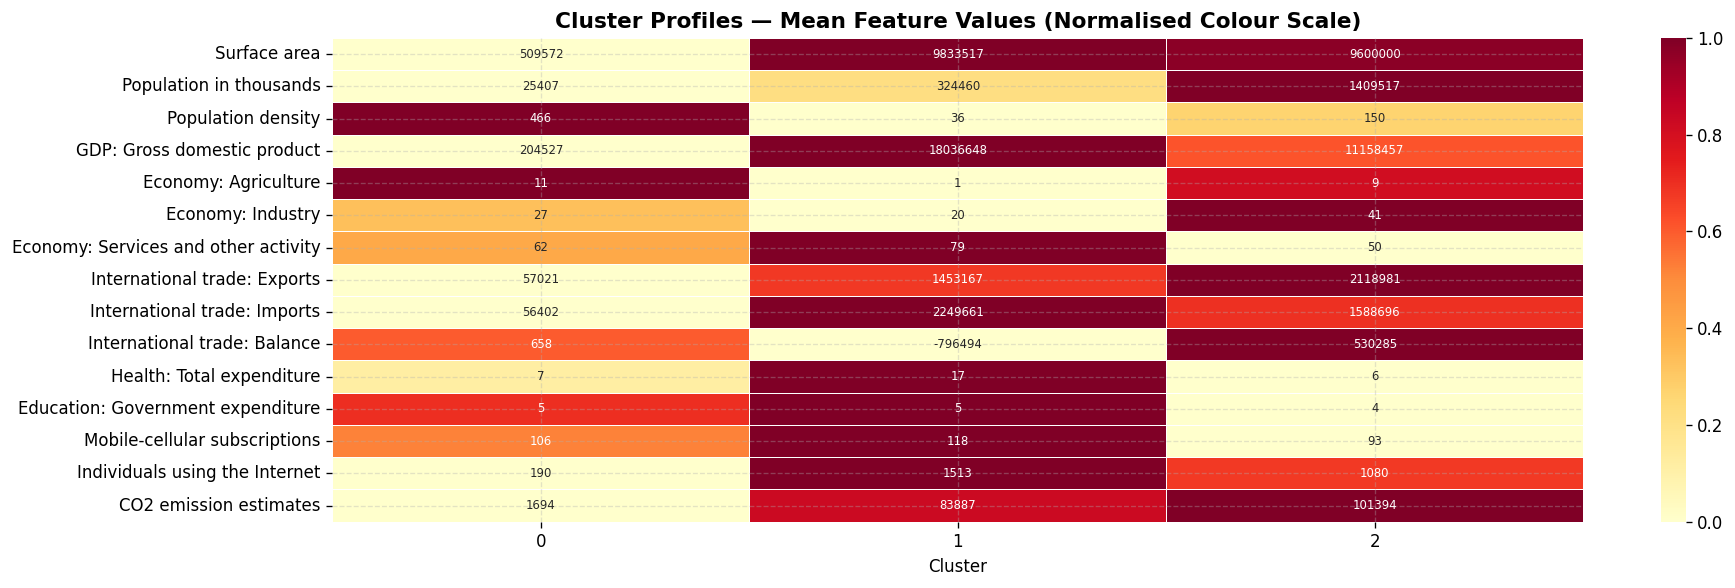

In [36]:
# Heatmap of cluster profiles
profile_norm = (final_profile[num_cols] - final_profile[num_cols].min()) / \
               (final_profile[num_cols].max() - final_profile[num_cols].min())

plt.figure(figsize=(16, 5))
sns.heatmap(profile_norm.T, annot=final_profile[num_cols].T,
            fmt='.0f', cmap='YlOrRd',
            linewidths=0.4, annot_kws={'size': 7})
plt.title('Cluster Profiles — Mean Feature Values (Normalised Colour Scale)',
          fontsize=13, fontweight='bold')
plt.xlabel('Cluster')
plt.tight_layout()
plt.savefig('plot_14_cluster_profiles.png', bbox_inches='tight')
plt.show()

## 15. Conclusions

This project applied a complete unsupervised learning pipeline to 229 countries.

**Preprocessing:**
- Missing values (-99 and ...) were replaced with NaN and imputed using **regional median imputation**, preserving geographic similarity between countries
- All features were standardised using StandardScaler before clustering

**Hierarchical Clustering:**
- Cophenetic Correlation identified the best linkage method from six candidates
- Optimal K was selected by evaluating all cuts K=2 to K=10 using Silhouette, Davies-Bouldin, and Calinski-Harabasz indices
- The dendrogram revealed the nested structure of country groupings

**K-Means Clustering:**
- Elbow Method identified candidate K values
- Optimal K confirmed by evaluation metrics across K=2 to K=10

**Comparison:**
- Both algorithms agreed broadly on the cluster structure, validated by Adjusted Rand Index
- Metric scores determined which algorithm produced more compact, well-separated clusters

**PCA** confirmed visual separation of clusters in 2D space.

---
*Analysis by Takunda Manhongo — BSc Data Science and Systems, University of Zimbabwe, 2026*